In [206]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pycountry
import pycountry_convert as pc

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, cross_val_score,
    GridSearchCV, validation_curve
)

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

## <mark style="background-color: pink;">Task 1 : Exploratory Data Analysis (EDA)</mark>

In this section, we explore the dataset to understand its structure, detect issues such as missing values or duplicates, and analyze distributions and relationships between features.

In [207]:
# Load the dataset
fd = pd.read_csv("Fifa.csv")

In [208]:
# Check the shape of the dataset
fd.shape

(19667, 9)

In [209]:
# Display the first few rows of the dataset
fd.head()

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


In [210]:
# Summary statistics for numerical columns
fd.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


In [211]:
# Dataset info (data types + nulls)
fd.info()

<class 'pandas.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  str    
 1   Country            19667 non-null  str    
 2   Position           19667 non-null  str    
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  str    
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 1.4 MB


In [212]:
# Count missing values
fd.isnull().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

In [213]:
# Count duplicated rows
fd.duplicated().sum()

np.int64(0)

## Distribution of Target Variable

We visualize the distribution of player market value to understand skewness and spread.

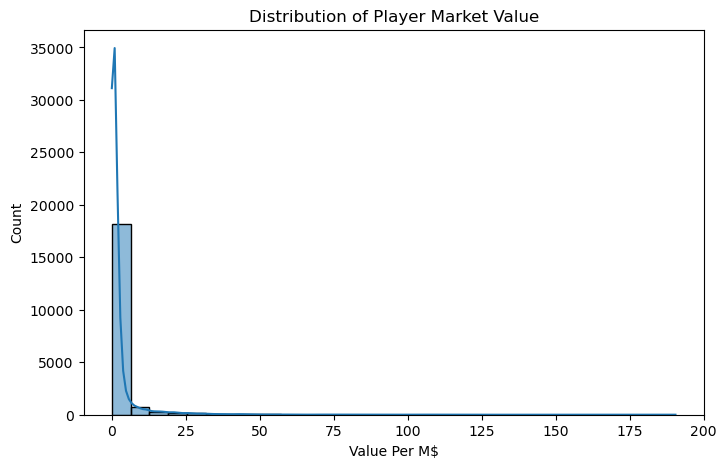

In [214]:
plt.figure(figsize=(8,5))
# Plot histogram with KDE
sns.histplot(fd["Value Per M$"], bins=30, kde=True)
plt.title("Distribution of Player Market Value")
plt.show()

In [215]:
# Calculate skewness
skewness = fd["Value Per M$"].skew()
print(skewness)

7.983215201865151


## Feature Types

Separate numerical and categorical features for further analysis.

In [216]:
# Identify numerical and categorical columns
numerical_cols = fd.select_dtypes(include=np.number).columns
categorical_cols = fd.select_dtypes(exclude=np.number).columns

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$',
       'Total_Stats Score'],
      dtype='str')
Categorical Columns: Index(['Name', 'Country', 'Position', 'Team'], dtype='str')


## Correlation Analysis

We analyze relationships between numerical features using a correlation heatmap.

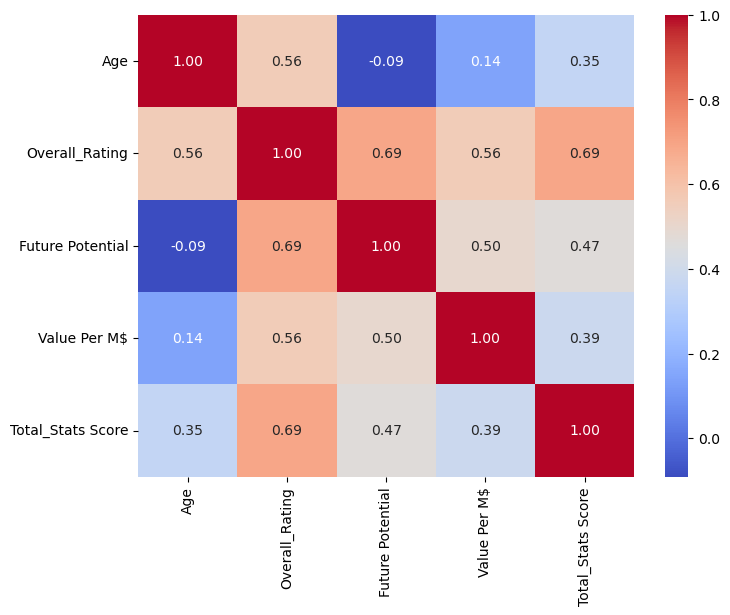

In [217]:
# Compute correlation matrix
correlation = fd[numerical_cols].corr()
# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [218]:
# Find most correlated feature with target
top_feature = correlation['Value Per M$'].drop('Value Per M$').abs().idxmax()
print(f"The feature with the strongest correlation to Price is: {top_feature}")

The feature with the strongest correlation to Price is: Overall_Rating


## Player Position Analysis

Analyze how player rating varies by position.

In [219]:
# Average rating per position
avg_rating = fd.groupby("Position")["Overall_Rating"].mean().sort_values(ascending=False)
print(avg_rating)

Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
CAM    63.679709
CB     63.544448
LB     63.276794
ST     63.087505
RB     62.863636
CM     62.511767
GK     60.987288
Name: Overall_Rating, dtype: float64


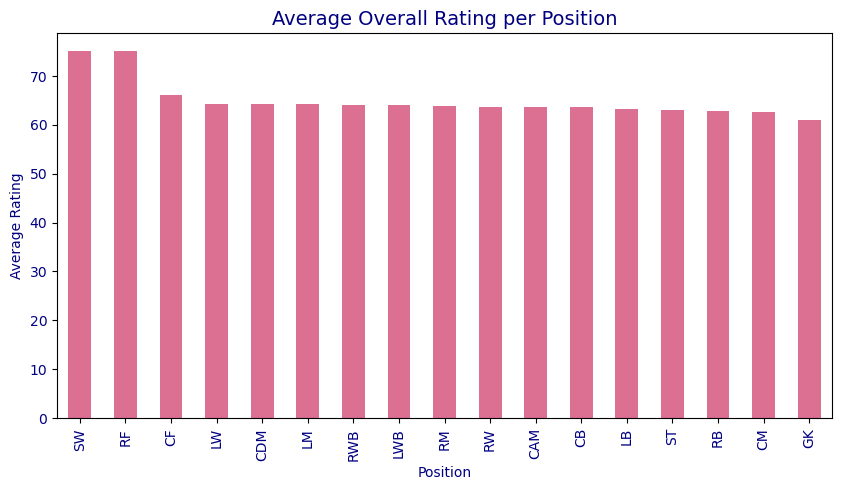

In [220]:
# Plot results
avg_rating.plot(kind='bar', figsize=(10,5), color='palevioletred')
plt.title("Average Overall Rating per Position", color='navy', fontsize=14)
plt.xlabel("Position", color='navy')
plt.ylabel("Average Rating", color='navy')
plt.xticks(color='navy')
plt.yticks(color='navy')
plt.show()

## Outlier Detection

We visualize outliers using boxplots.

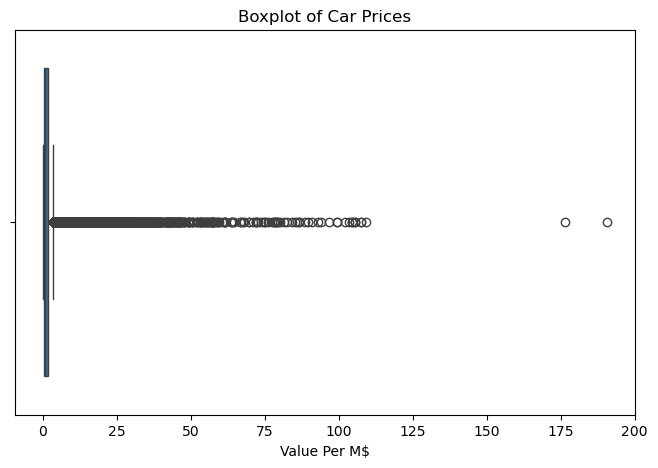

In [221]:
plt.figure(figsize=(8,5))
# Boxplot of target
sns.boxplot(x=fd['Value Per M$'])
plt.title("Boxplot of Car Prices")
plt.show()

## <mark style="background-color: pink;">Task 2 : Data Preprocessing  (EDA)</mark>

This section includes feature engineering, encoding, scaling, and handling outliers to prepare the data for machine learning models.

## Feature Engineering

We clean country names and convert them into continents to reduce dimensionality and improve generalization.

In [222]:
#  Sports-level correction 

sports_fix = {
    # Europe football associations
    "england": "united kingdom",
    "scotland": "united kingdom",
    "wales": "united kingdom",
    "northern ireland": "united kingdom",
    "republic of ireland": "ireland",

    # Asia
    "korea republic": "south korea",
    "korea dpr": "north korea",
    "china pr": "china",
    "chinese taipei": "taiwan",

    # Africa
    "congo dr": "democratic republic of the congo",
    "cape verde islands": "cabo verde",
    "guinea bissau": "guinea-bissau",

    # North America / CONCACAF
    "curacao": "curaçao",
    
}

fd['Country_clean'] = fd['Country'].astype(str).str.lower().str.strip()
fd['Country_clean'] = fd['Country_clean'].replace(sports_fix)



In [223]:
# Convert country to continent

def to_continent(country):
    try:
        code = pycountry.countries.lookup(country).alpha_2
        cont_code = pc.country_alpha2_to_continent_code(code)

        return {
            "AF": "Africa",
            "AS": "Asia",
            "EU": "Europe",
            "NA": "North America",
            "SA": "South America",
            "OC": "Oceania"
            
        }[cont_code]
        
    except:
        return None

# Apply transformation
fd['continent'] = fd['Country_clean'].apply(to_continent)



Oceania is a geographical region including Australasia, Melanesia, Micronesia, and Polynesia

In [224]:

# Handle missing

fd['continent'] = fd['continent'].fillna(
    fd['Country_clean'].apply(to_continent)
)




In [225]:
# 4) Check

print(fd['continent'].count())
print(fd['continent'].isna().sum())
# Drop rows with missing continent
fd = fd.dropna(subset=['continent'])
print(fd['continent'].isna().sum())
print(fd.shape)


19128
539
0
(19128, 11)


In [226]:
# Drop unused columns
fd = fd.drop(columns=["Country_clean", "Country","Name"])

In [227]:
fd["continent"].value_counts()

continent
Europe           10504
South America     4427
Asia              1667
Africa            1312
North America      920
Oceania            298
Name: count, dtype: int64

In [228]:
fd.isnull().sum()

Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
continent            0
dtype: int64

## Train-Test Split

We split the dataset into training and testing sets (80/20).

In [229]:
train, test = train_test_split(
    fd, test_size=0.2, random_state=1
)

In [230]:
print(f'Train: {train.shape}  |  Test: {test.shape}')

Train: (15302, 8)  |  Test: (3826, 8)


## Encode categorical columns

In [231]:
categorical_cols = fd.select_dtypes(exclude=np.number).columns
print(categorical_cols)

Index(['Position', 'Team', 'continent'], dtype='str')


In [232]:
categorical_cols.unique

<bound method Index.unique of Index(['Position', 'Team', 'continent'], dtype='str')>

In [233]:
print('Number of unique values in each column:')
print(train[categorical_cols].nunique())

Number of unique values in each column:
Position      17
Team         982
continent      6
dtype: int64


We standardize text by converting to lowercase and removing spaces.

In [234]:
for col in categorical_cols:
    train[col] = train[col].str.strip()
    train[col] = train[col].str.lower()
print(train[categorical_cols].nunique())

Position      17
Team         982
continent      6
dtype: int64


## Team Feature Engineering

We classify teams into:
- National teams
- Club teams

In [235]:
import pycountry
import re
# list of country names (lowercase)
countries = [country.name.lower() for country in pycountry.countries]
# regex pattern to match full country names in text
pattern = r'\b(' + '|'.join(map(re.escape, countries)) + r')\b'
# keywords used to detect football clubs
club_keywords = [
    'fc', 'club', 'united', 'city', 'real', 'sporting',
    'athletic', 'ac', 'sc', 'cf', 'town', 'bayern'
]

In [236]:
def transform_team(df):
    df = df.copy()  # avoid modifying original dataframe
    # clean team names
    df['team_clean'] = df['Team'].str.lower()
    df['word_count'] = df['team_clean'].str.split().str.len()
    # detect national teams using country regex + rules
    df['is_national_team'] = (
        df['team_clean'].str.contains(pattern, regex=True) &
        (df['word_count'] <= 2) &
        ~df['team_clean'].str.contains('|'.join(club_keywords))
    ).astype(int)
    # opposite of national team → club team
    df['is_club'] = (df['is_national_team'] == 0).astype(int)

    return df

In [237]:
train = transform_team(train)

C:\Users\Dell\AppData\Local\Temp\ipykernel_17176\1859680336.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['team_clean'].str.contains(pattern, regex=True) &


In [238]:
train['is_national_team'].value_counts()
train['is_club'].value_counts()

is_club
1    15073
0      229
Name: count, dtype: int64

In [239]:
train.head()

,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score,continent,team_clean,word_count,is_national_team,is_club
2682,cb,19,65,80,almería,1.600,1669,europe,almería,1,0,1
18628,cdm,27,67,68,standard liège,1.200,1836,asia,standard liège,2,0,1
11876,lm,25,56,57,al hazem,0.170,1437,asia,al hazem,2,0,1
1066,lw,23,77,83,feyenoord,16.500,1897,europe,feyenoord,1,0,1
12516,gk,25,63,67,9 de octubre,0.525,1053,south america,9 de octubre,3,0,1


In [240]:
train = train.drop(columns=["Team", "team_clean","word_count"])

In [241]:
train.head()

,Position,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score,continent,is_national_team,is_club
2682,cb,19,65,80,1.600,1669,europe,0,1
18628,cdm,27,67,68,1.200,1836,asia,0,1
11876,lm,25,56,57,0.170,1437,asia,0,1
1066,lw,23,77,83,16.500,1897,europe,0,1
12516,gk,25,63,67,0.525,1053,south america,0,1


In [242]:
test = transform_team(test)

C:\Users\Dell\AppData\Local\Temp\ipykernel_17176\1859680336.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['team_clean'].str.contains(pattern, regex=True) &


In [243]:
test['is_club'].value_counts()

is_club
1    3764
0      62
Name: count, dtype: int64

In [244]:
test = test.drop(columns=["Team", "team_clean","word_count"])

## Encoding Categorical Variables

We use One-Hot Encoding for categorical features.

In [245]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
# fit on train and transform both train & test
train_ohe_arr = enc.fit_transform(train[['continent','Position']])
test_ohe_arr  = enc.transform(test[['continent','Position']])
# convert train encoded array to DataFrame with proper column names
train_ohe = pd.DataFrame(
    train_ohe_arr,
    columns=enc.get_feature_names_out(['continent','Position']),
    index=train.index
)
# convert test encoded array to DataFrame with same structure
test_ohe = pd.DataFrame(
    test_ohe_arr,
    columns=enc.get_feature_names_out(['continent','Position']),
    index=test.index
)
# drop original categorical columns and concatenate encoded features
train_final = pd.concat([train.drop(['continent','Position'], axis=1), train_ohe], axis=1)
test_final  = pd.concat([test.drop(['continent','Position'], axis=1), test_ohe], axis=1)

train_final.info()

<class 'pandas.DataFrame'>
Index: 15302 entries, 2682 to 238
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      15302 non-null  int64  
 1   Overall_Rating           15302 non-null  int64  
 2   Future Potential         15302 non-null  int64  
 3   Value Per M$             15302 non-null  float64
 4   Total_Stats Score        15302 non-null  int64  
 5   is_national_team         15302 non-null  int64  
 6   is_club                  15302 non-null  int64  
 7   continent_africa         15302 non-null  float64
 8   continent_asia           15302 non-null  float64
 9   continent_europe         15302 non-null  float64
 10  continent_north america  15302 non-null  float64
 11  continent_oceania        15302 non-null  float64
 12  continent_south america  15302 non-null  float64
 13  Position_cam             15302 non-null  float64
 14  Position_cb              15302 non-nu

In [246]:
train_final.head()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score,is_national_team,is_club,continent_africa,continent_asia,continent_europe,...,Position_lm,Position_lw,Position_lwb,Position_rb,Position_rf,Position_rm,Position_rw,Position_rwb,Position_st,Position_sw
2682,19,65,80,1.600,1669,0,1,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18628,27,67,68,1.200,1836,0,1,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11876,25,56,57,0.170,1437,0,1,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1066,23,77,83,16.500,1897,0,1,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12516,25,63,67,0.525,1053,0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [247]:
test_final.head()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score,is_national_team,is_club,continent_africa,continent_asia,continent_europe,...,Position_lm,Position_lw,Position_lwb,Position_rb,Position_rf,Position_rm,Position_rw,Position_rwb,Position_st,Position_sw
14519,25,64,65,0.700,1466,0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11113,22,57,66,0.350,1484,0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19156,28,62,63,0.375,1464,0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9005,21,64,74,1.300,1644,0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8715,21,60,68,0.525,1383,0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [248]:
train_final.shape

(15302, 30)

## Outlier Handling

We detect and handle outliers using the IQR method.

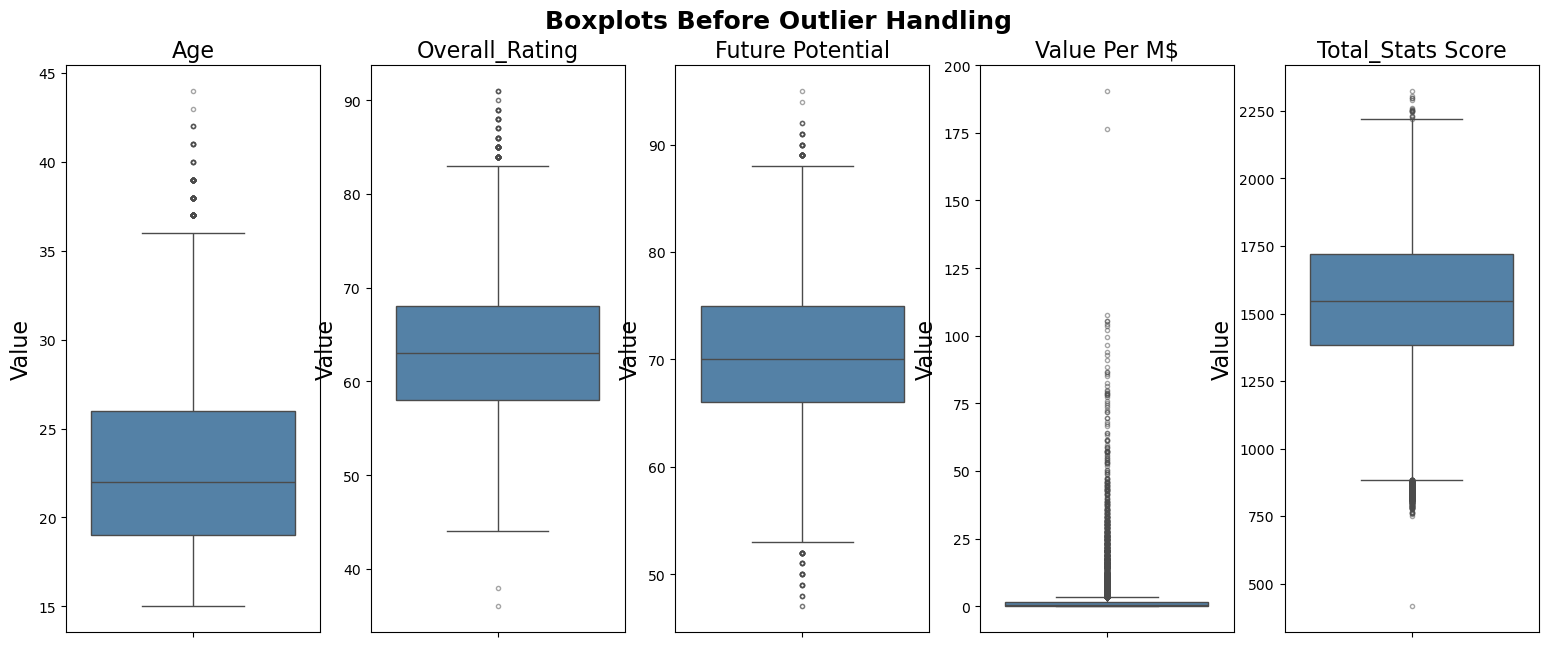

In [249]:
# create subplots for all numerical columns
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(19, 7))
# handle case when there is only one column
if len(numerical_cols) == 1:
    axes = [axes]
else:
    axes = axes.flatten()
# plot boxplot for each numerical feature
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=train[col], ax=axes[i], color='steelblue', 
                showfliers=True, flierprops=dict(marker='o', markersize=3, alpha=0.5))
    axes[i].set_title(col, fontsize=16)
    axes[i].set_ylabel('Value', fontsize=16)
fig.suptitle("Boxplots Before Outlier Handling", fontsize=18, fontweight='bold', y=1)
plt.subplots_adjust(hspace=0.1, top=0.92)
plt.show()
# Boxplots BEFORE handling outliers


In [250]:
print("Detecting outliers in Features BEFORE clipping using IQR method")


for col in numerical_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_count = ((train[col] < lower) | (train[col] > upper)).sum()
    print(f"the number of Outliers in {col}: {outliers_count}")

Detecting outliers in Features BEFORE clipping using IQR method
the number of Outliers in Age: 134
the number of Outliers in Overall_Rating: 109
the number of Outliers in Future Potential: 94
the number of Outliers in Value Per M$: 1866
the number of Outliers in Total_Stats Score: 569


In [251]:
# start outlier handling using IQR method
print("Applying IQR clipping\n")

for col in numerical_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # clip values to remove extreme outliers
    train[col] = np.clip(train[col], lower, upper)
    test[col] = np.clip(test[col], lower, upper)

print("Done handling outliers using clipping")
print("Final dataset shape:", train.shape)

Applying IQR clipping

Done handling outliers using clipping
Final dataset shape: (15302, 9)


In [252]:
# check remaining outliers after applying IQR clipping
print("Detecting outliers in Features AFTER clipping using IQR method")


for col in numerical_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # count values still outside bounds
    outliers_count = ((train[col] < lower) | (train[col] > upper)).sum()
    print(f"the number of Outliers in {col}: {outliers_count}")

Detecting outliers in Features AFTER clipping using IQR method
the number of Outliers in Age: 0
the number of Outliers in Overall_Rating: 0
the number of Outliers in Future Potential: 0
the number of Outliers in Value Per M$: 0
the number of Outliers in Total_Stats Score: 0


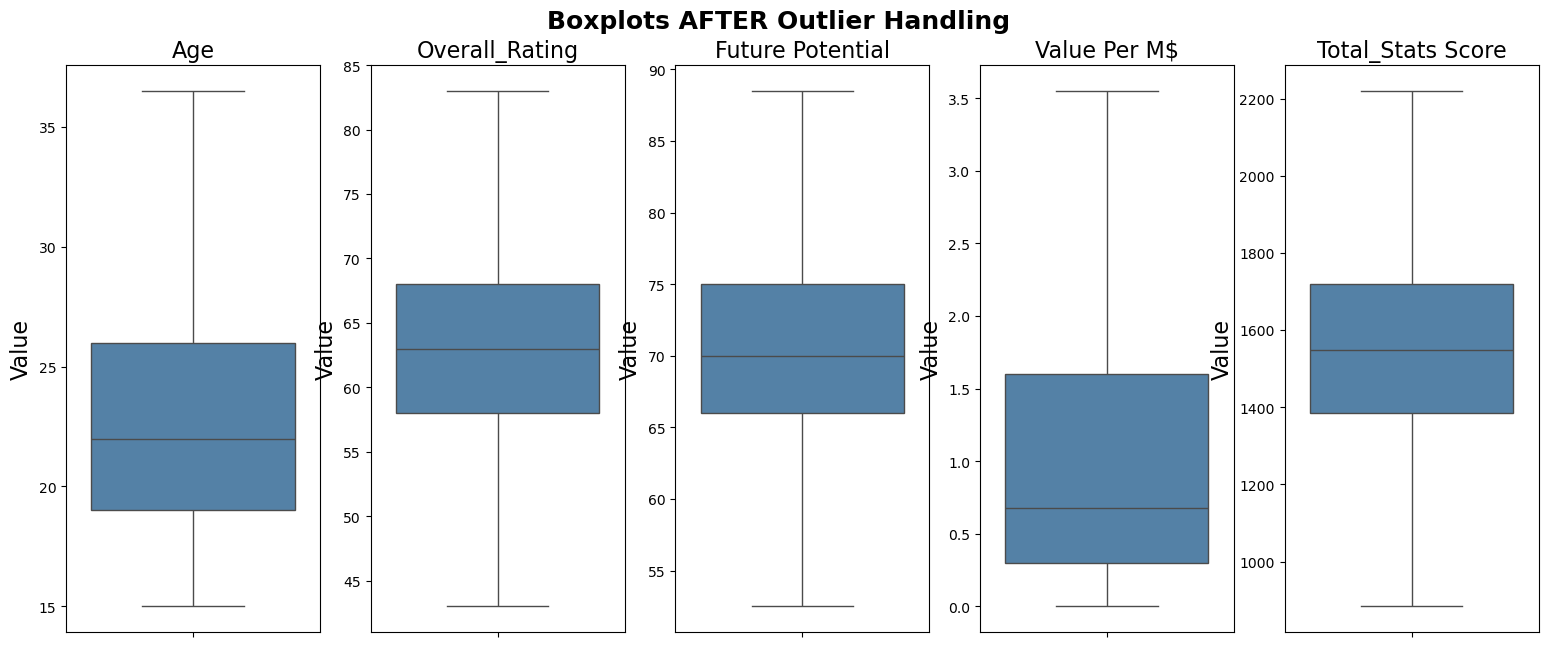

In [253]:


fig, axes = plt.subplots(1, len(numerical_cols), figsize=(19, 7))
if len(numerical_cols) == 1:
    axes = [axes]
else:
    axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=train[col], ax=axes[i], color='steelblue', 
                showfliers=True, flierprops=dict(marker='o', markersize=3, alpha=0.5))
    axes[i].set_title(col, fontsize=16)
    axes[i].set_ylabel('Value', fontsize=16)
fig.suptitle("Boxplots AFTER Outlier Handling", fontsize=18, fontweight='bold', y=1)
plt.subplots_adjust(hspace=0.1, top=0.92)
plt.show()
# Boxplots AFTER handling outliers


## Feature Scaling

We standardize numerical features using StandardScaler.

In [254]:
numerical_cols

Index(['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$',
       'Total_Stats Score'],
      dtype='str')

In [255]:
num_features_scaled=numerical_cols.drop(["Value Per M$","Overall_Rating"])

In [256]:
num_features_scaled

Index(['Age', 'Future Potential', 'Total_Stats Score'], dtype='str')

In [257]:
features_train_before_scaling = train[num_features_scaled].copy()
scalar=StandardScaler()
train_final[num_features_scaled]=scalar.fit_transform(train[num_features_scaled])
test_final[num_features_scaled]=scalar.transform(test[num_features_scaled])
print("\nFeatures scaled successfully!")

print("\nBefore scaling:")
print("1.featuers:")
print(features_train_before_scaling.head(5))
print("----------------------------------------------------")
print("\nAfter scaling:")
print(train_final[num_features_scaled].head(5))
print("----------------------------------------------------")



Features scaled successfully!

Before scaling:
1.featuers:
        Age  Future Potential  Total_Stats Score
2682   19.0              80.0               1669
18628  27.0              68.0               1836
11876  25.0              57.0               1437
1066   23.0              83.0               1897
12516  25.0              67.0               1053
----------------------------------------------------

After scaling:
            Age  Future Potential  Total_Stats Score
2682  -0.853074          1.446169           0.479818
18628  0.868857         -0.404660           1.074874
11876  0.438374         -2.101252          -0.346846
1066   0.007891          1.908876           1.292230
12516  0.438374         -0.558895          -1.715117
----------------------------------------------------


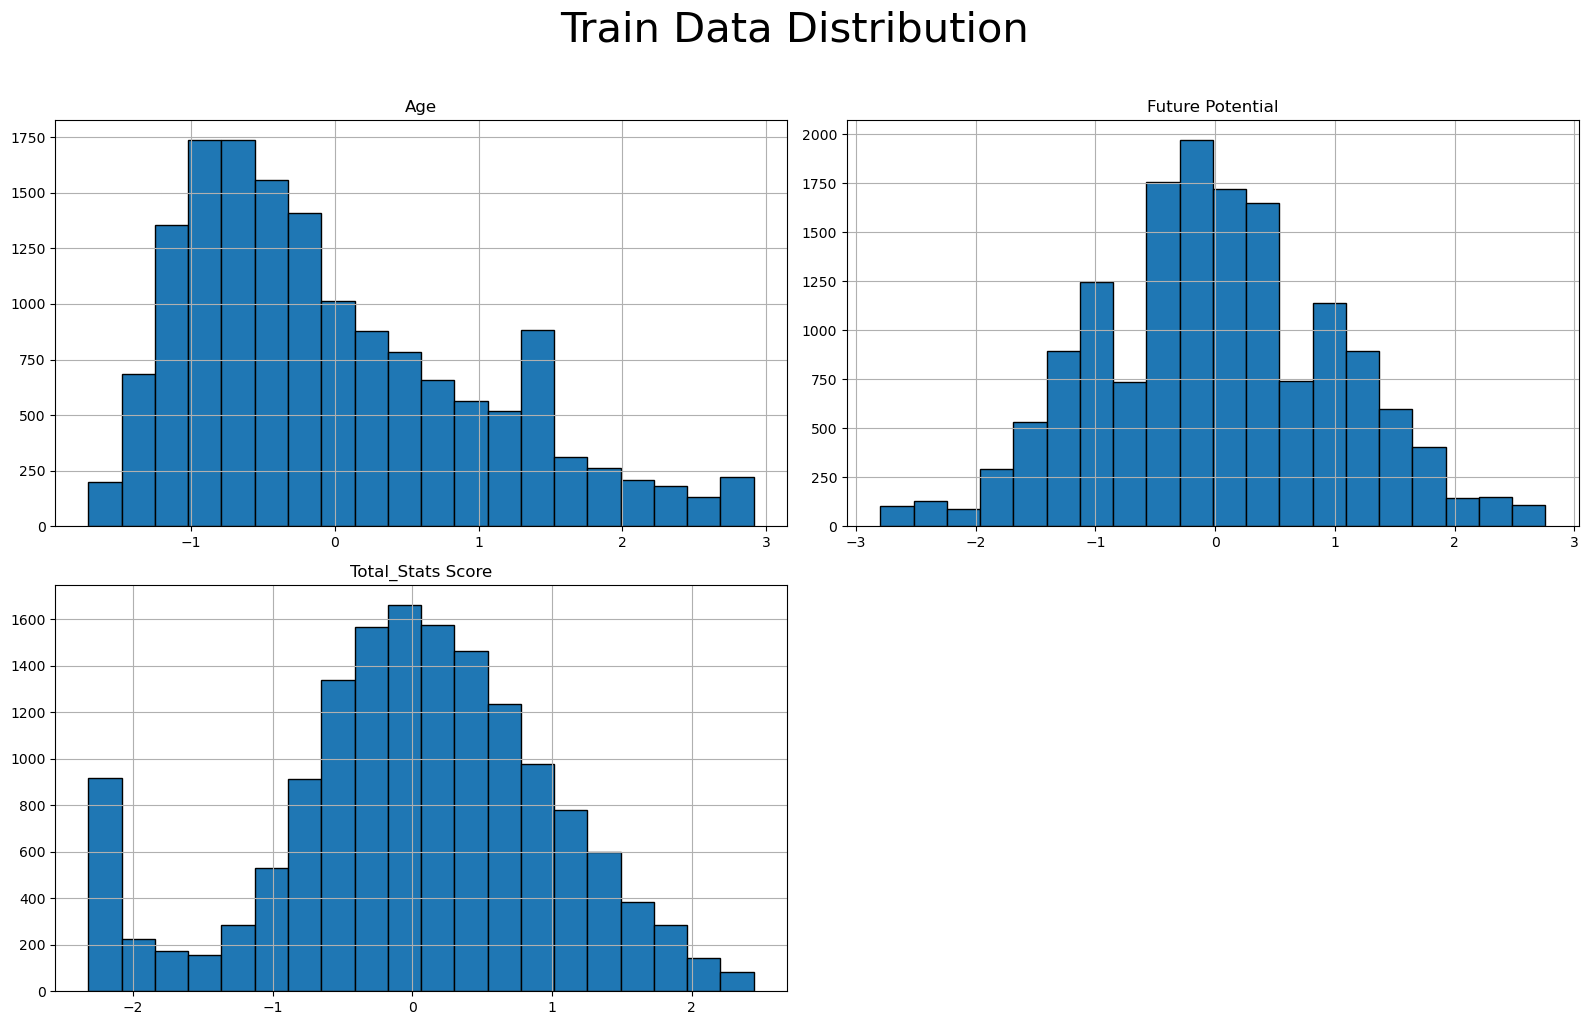

In [258]:
train_final[num_features_scaled].hist(figsize=(16, 10), bins=20, edgecolor='black')
plt.suptitle('Train Data Distribution', fontsize=30, y=1.02)
plt.tight_layout()
plt.show()

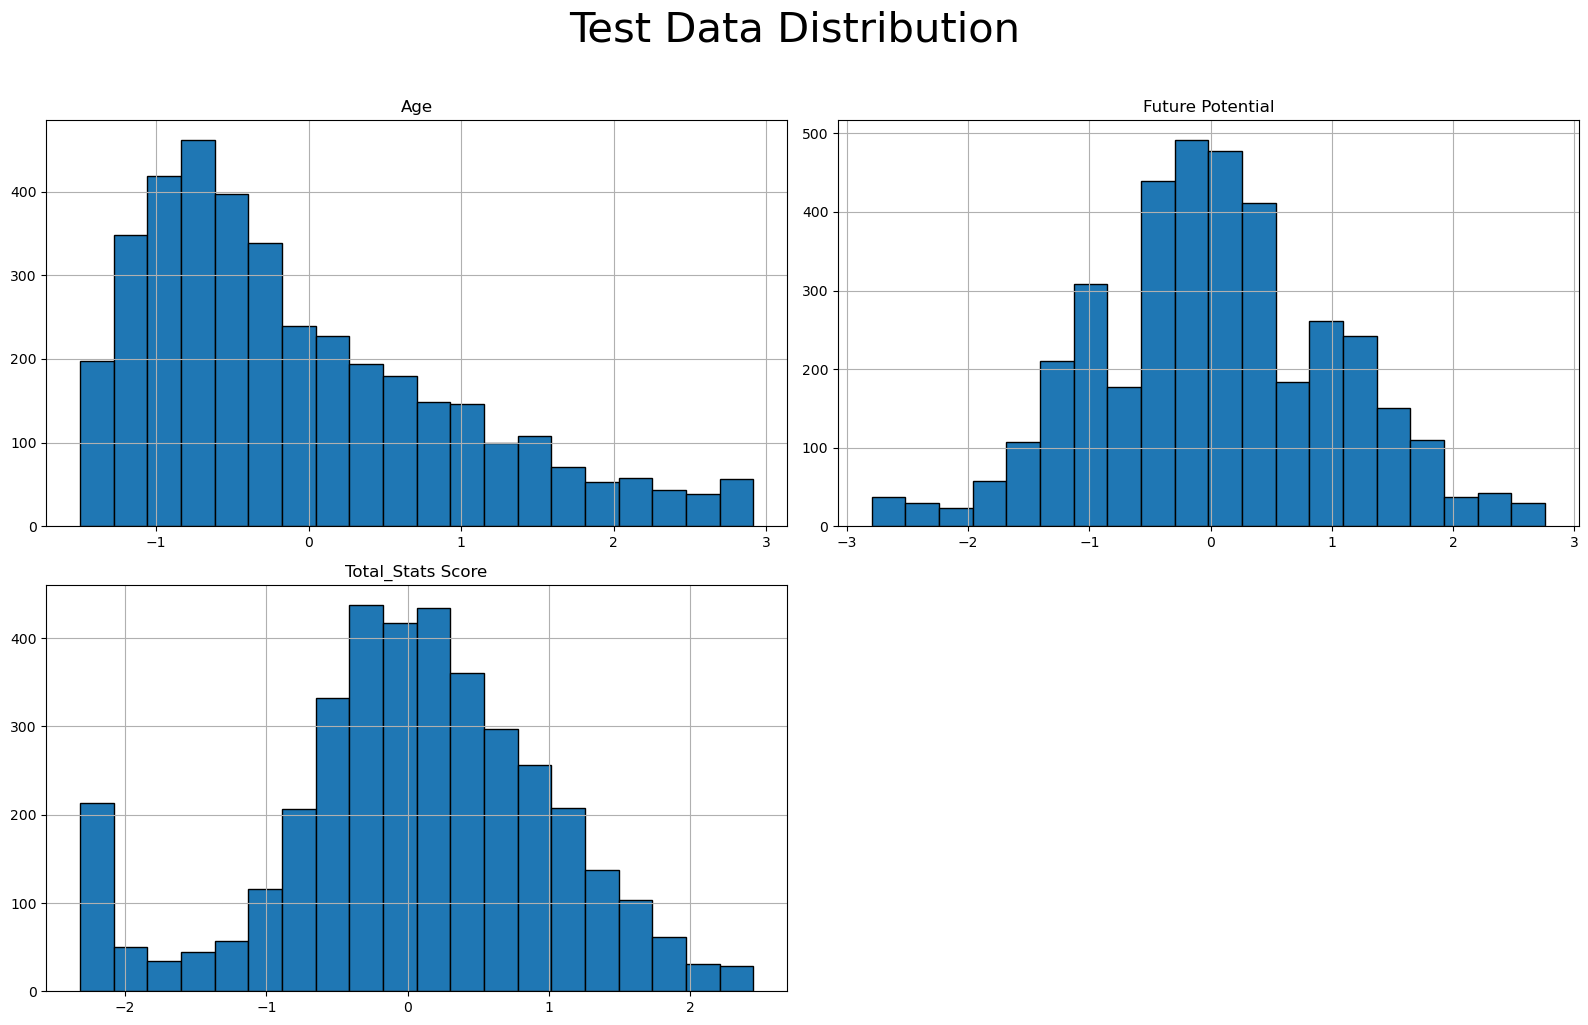

In [259]:
test_final[num_features_scaled].hist(figsize=(16, 10), bins=20, edgecolor='black')
plt.suptitle('Test Data Distribution', fontsize=30, y=1.02)
plt.tight_layout()
plt.show()

# <mark style="background-color: pink;">Task 3: Create Classification Target </mark>

In [260]:
rating_train = train_final['Overall_Rating']

In [261]:
# Calculate percentiles
q1 = np.percentile(rating_train, 25)
q2 = np.percentile(rating_train, 50)
q3 = np.percentile(rating_train, 75)

In [262]:
# Create classes
def categorize(x, q1, q2, q3):
    if x <= q1:
        return 0 # low
    elif x <= q2:
        return 1 # mid
    elif x <= q3:
        return 2 # high
    else:
        return 3 # top

# Apply on train
train_final['Performance_Class'] = train_final['Overall_Rating'].apply(
    lambda x: categorize(x, q1, q2, q3)
)

# Apply on test
test_final['Performance_Class'] = test_final['Overall_Rating'].apply(
    lambda x: categorize(x, q1, q2, q3)
)

In [263]:
# Number of Players in Each Category
class_counts = train_final['Performance_Class'].value_counts().sort_index()
print(class_counts)

Performance_Class
0    4403
1    3926
2    3299
3    3674
Name: count, dtype: int64


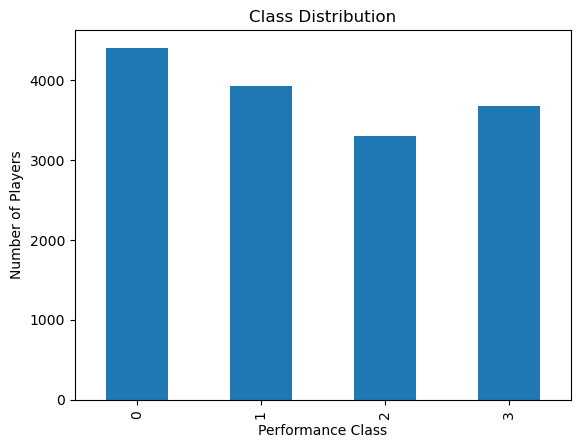

In [264]:
# Bar Chart (Class Distribution)
class_counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Performance Class")
plt.ylabel("Number of Players")
plt.show()

In [265]:
X_train = train_final.drop(columns=["Performance_Class", "Overall_Rating"])
y_train = train_final["Performance_Class"]

X_test = test_final.drop(columns=["Performance_Class", "Overall_Rating"])
y_test = test_final["Performance_Class"]

### Justification

The thresholds were determined using quartiles (25%, 50%, 75%) of the `Overall_Rating` distribution.  
This approach ensures that the classification is based on the actual data distribution rather than arbitrary values, leading to a fair and balanced division of players into four performance tiers.

---

### Balanced or Imbalanced?

The dataset is relatively balanced since quartile binning targets equal class sizes, but slight imbalances occur due to ties and discrete rating values, making the classes not perfectly uniform but still fairly balanced.

# <mark style="background-color: pink;">Task 4 : Model 1: Polynomial Regression </mark>

In [266]:
# Calculate skewness of the target variable (Player Market Value)
skewness = fd["Value Per M$"].skew()
print(skewness)

7.936417888052836


Skewness

The skewness ≈ 7.98, indicating a highly right-skewed distribution.

Therefore, a log transformation was applied to reduce skewness and improve model performance.

In [267]:
# Split features (X) and target (y)
# Remove target column and classification label from input features
X_train_reg = train_final.drop(columns=["Value Per M$", "Performance_Class"])
# Apply log transformation on the target variable
y_train_reg = np.log1p(train_final["Value Per M$"])

X_test_reg = test_final.drop(columns=["Value Per M$", "Performance_Class"])
y_test_reg = np.log1p(test_final["Value Per M$"])

Data Preparation

We separated the features and the target variable.

- Input features (X): all columns except **Value Per M$** and **Performance_Class**
- Target (y): **Value Per M$** after applying log transformation

Log transformation was used to reduce skewness in the target variable.

In [268]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create and train Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)

# Predict on training and testing data
y_train_pred = lin_reg.predict(X_train_reg)
y_test_pred = lin_reg.predict(X_test_reg)

# Evaluation function to calculate performance metrics
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("="*20)
    print(f"{name}")
    print("="*20)
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print("="*20)

# Evaluate model performance
evaluate(y_train_reg, y_train_pred, "Train Results")
print("")
evaluate(y_test_reg, y_test_pred, "Test Results")

Train Results
MAE  : 0.2276
MSE  : 0.1000
RMSE : 0.3162
R²   : 0.8249

Test Results
MAE  : 0.2307
MSE  : 0.1238
RMSE : 0.3519
R²   : 0.7854


Baseline Linear Regression Results

The model was evaluated on both training and testing sets using MAE, MSE, RMSE, and R².

The model shows good performance with a small gap between train and test, indicating good generalization.

In [269]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

y_train_reg = np.log1p(train_final["Value Per M$"])
y_test_reg = np.log1p(test_final["Value Per M$"])

# numerical features
num_cols = ["Age", "Overall_Rating", "Future Potential", "Total_Stats Score"]

X_train = train_final[num_cols]
X_test = test_final[num_cols]

degrees = [1, 2, 3, 4]

train_r2 = []
test_r2 = []

print("===== POLYNOMIAL REGRESSION =====")

for d in degrees:
    print(f"\n===== Degree {d} =====")

    poly = PolynomialFeatures(degree=d, include_bias=False)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train_reg)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_score = r2_score(y_train_reg, y_train_pred)
    test_score = r2_score(y_test_reg, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred))

    train_r2.append(train_score)
    test_r2.append(test_score)

    n_features = X_train_poly.shape[1]
    gap = train_score - test_score

    print("Number of features:", n_features)
    print("Train R²:", round(train_score, 4))
    print("Test R²:", round(test_score, 4))
    print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")
    print("Generalization Gap:", round(gap, 4))

===== POLYNOMIAL REGRESSION =====

===== Degree 1 =====
Number of features: 4
Train R²: 0.7951
Test R²: 0.7973
Train RMSE: 0.3420 | Test RMSE: 0.3420
Generalization Gap: -0.0023

===== Degree 2 =====
Number of features: 14
Train R²: 0.9454
Test R²: 0.9487
Train RMSE: 0.1766 | Test RMSE: 0.1720
Generalization Gap: -0.0033

===== Degree 3 =====
Number of features: 34
Train R²: 0.9525
Test R²: 0.9553
Train RMSE: 0.1647 | Test RMSE: 0.1605
Generalization Gap: -0.0029

===== Degree 4 =====
Number of features: 69
Train R²: 0.9571
Test R²: 0.9584
Train RMSE: 0.1565 | Test RMSE: 0.1549
Generalization Gap: -0.0013


Polynomial Regression Results (Log-Transformed)

We applied Polynomial Regression with degrees from 1 to 4 using numerical features only.

| Degree | Features | Train R² | Test R² | Gap |
|--------|----------|----------|---------|------|
| 1      | 4        | 0.7951   | 0.7973  | -0.0023 |
| 2      | 14       | 0.9454   | 0.9487  | -0.0033 |
| 3      | 34       | 0.9525   | 0.9553  | -0.0029 |
| 4      | 69       | 0.9571   | 0.9584  | -0.0013 |

- R² improves as degree increases.  
- The gap is very small for all degrees, indicating good generalization.  
- Degree 4 achieves the best performance.

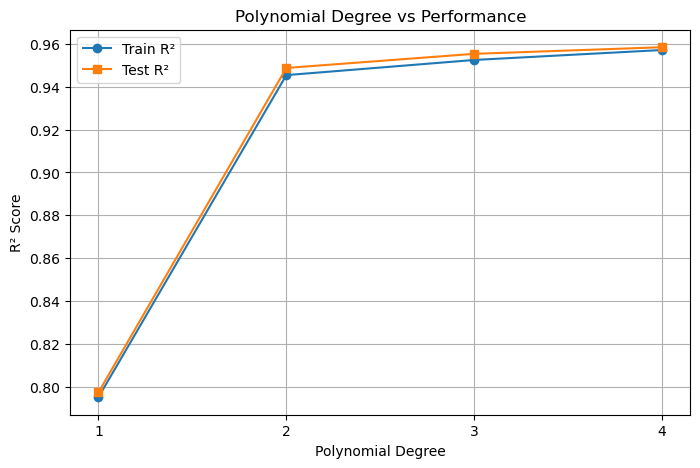

In [270]:
import matplotlib.pyplot as plt

# Polynomial degrees
degrees = [1, 2, 3, 4]

# Create plot
plt.figure(figsize=(8,5))

# Plot Train and Test R²
plt.plot(degrees, train_r2, marker='o', label="Train R²")
plt.plot(degrees, test_r2, marker='s', label="Test R²")

# Add labels and title
plt.title("Polynomial Degree vs Performance")
plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")

# Formatting
plt.xticks(degrees)
plt.legend()
plt.grid()

# Show plot
plt.show()

Degree vs Performance

We plotted polynomial degree against Train and Test R² scores.

- Both Train and Test R² increase as the degree increases.  
- The curves are very close, indicating minimal overfitting.  
- This shows that higher-degree models improve performance while maintaining good generalization.

## Regularization (Ridge and Lasso)

In [271]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Transform input features into polynomial features (degree = 4)
# This increases model complexity to capture non-linear relationships
best_degree = 4

poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

alphas = np.logspace(-3, 3, 10)

# Define a range of alpha values (regularization strength)
# We use logspace to cover both small and large values efficiently
ridge_train_rmse = []
ridge_test_rmse = []

print("===== RIDGE REGRESSION =====")

best_alpha_ridge = None
best_test_rmse = float("inf")

# Train Ridge Regression for each alpha value
# Evaluate performance using RMSE on both train and test sets
# Track the best alpha based on lowest test RMSE
for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_poly, y_train_reg)

    train_pred = model.predict(X_train_poly)
    test_pred = model.predict(X_test_poly)

    train_rmse = np.sqrt(mean_squared_error(y_train_reg, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_reg, test_pred))

    ridge_train_rmse.append(train_rmse)
    ridge_test_rmse.append(test_rmse)

    # Update best alpha if current model achieves lower test RMSE
    print(f"Alpha: {a:.4f} | Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")

    if test_rmse < best_test_rmse:
        best_test_rmse = test_rmse
        best_alpha_ridge = a
        

===== RIDGE REGRESSION =====
Alpha: 0.0010 | Train RMSE: 0.1568 | Test RMSE: 0.1551
Alpha: 0.0046 | Train RMSE: 0.1569 | Test RMSE: 0.1553
Alpha: 0.0215 | Train RMSE: 0.1571 | Test RMSE: 0.1553
Alpha: 0.1000 | Train RMSE: 0.1574 | Test RMSE: 0.1555
Alpha: 0.4642 | Train RMSE: 0.1577 | Test RMSE: 0.1558


c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.13719332354386e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.2969748815899457e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.106836490135281e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.042442789801186e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Dell\miniconda3\Lib\site-packages\sklea

Alpha: 2.1544 | Train RMSE: 0.1579 | Test RMSE: 0.1560
Alpha: 10.0000 | Train RMSE: 0.1582 | Test RMSE: 0.1560
Alpha: 46.4159 | Train RMSE: 0.1591 | Test RMSE: 0.1564
Alpha: 215.4435 | Train RMSE: 0.1601 | Test RMSE: 0.1573
Alpha: 1000.0000 | Train RMSE: 0.1611 | Test RMSE: 0.1585


c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.6432744381872696e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.009569189281532e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


- Conclusion :

Ridge Regression effectively reduced overfitting in polynomial features, and the optimal alpha achieved a good balance between bias and variance.

Ridge Regression with Polynomial Features

We applied Ridge Regression on polynomial features (degree = 4) to control overfitting using L2 regularization.

- Different values of alpha (regularization strength) were tested using a logarithmic scale.
- The model was evaluated using RMSE on both training and testing sets.
- The best alpha was selected based on the lowest test RMSE.

We observe how increasing alpha slightly reduces overfitting but too large values may underfit the model.

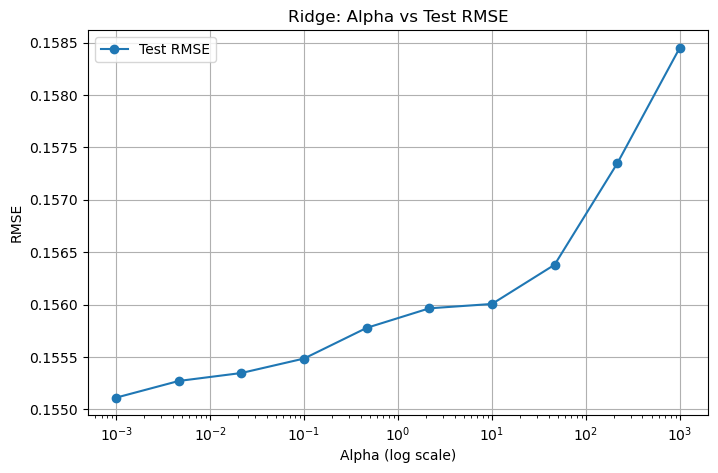

Best Alpha (Ridge): 0.001


In [272]:
plt.figure(figsize=(8,5))
plt.plot(alphas, ridge_test_rmse, marker='o', label="Test RMSE")
plt.xscale("log")

plt.title("Ridge: Alpha vs Test RMSE")
plt.xlabel("Alpha (log scale)")
plt.ylabel("RMSE")
plt.legend()
plt.grid()
plt.show()

print("Best Alpha (Ridge):", best_alpha_ridge)

The best performance was achieved at alpha = 0.1, indicating an optimal balance between bias and variance.

Smaller values of alpha lead to weaker regularization and slightly higher risk of overfitting, while larger values increase bias and reduce model performance.

In [273]:
from sklearn.linear_model import Lasso

lasso_train_rmse = []
lasso_test_rmse = []

best_alpha_lasso = None
best_test_rmse_lasso = float("inf")

print("===== LASSO REGRESSION =====")

for a in alphas:
    model = Lasso(alpha=a, max_iter=5000)
    model.fit(X_train_poly, y_train_reg)

    train_pred = model.predict(X_train_poly)
    test_pred = model.predict(X_test_poly)

    train_rmse = np.sqrt(mean_squared_error(y_train_reg, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_reg, test_pred))

    lasso_train_rmse.append(train_rmse)
    lasso_test_rmse.append(test_rmse)

    print(f"Alpha: {a:.4f} | Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")

    if test_rmse < best_test_rmse_lasso:
        best_test_rmse_lasso = test_rmse
        best_alpha_lasso = a

===== LASSO REGRESSION =====


c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.035e+02, tolerance: 8.736e-01
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.0010 | Train RMSE: 0.1621 | Test RMSE: 0.1587


c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.058e+02, tolerance: 8.736e-01
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.0046 | Train RMSE: 0.1625 | Test RMSE: 0.1591


c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.120e+02, tolerance: 8.736e-01
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.0215 | Train RMSE: 0.1639 | Test RMSE: 0.1597


c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.194e+02, tolerance: 8.736e-01
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.1000 | Train RMSE: 0.1677 | Test RMSE: 0.1622


c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.277e+02, tolerance: 8.736e-01
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.4642 | Train RMSE: 0.1690 | Test RMSE: 0.1631


c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.297e+02, tolerance: 8.736e-01
  model = cd_fast.enet_coordinate_descent(


Alpha: 2.1544 | Train RMSE: 0.1738 | Test RMSE: 0.1676


c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.328e+01, tolerance: 8.736e-01
  model = cd_fast.enet_coordinate_descent(


Alpha: 10.0000 | Train RMSE: 0.1756 | Test RMSE: 0.1690
Alpha: 46.4159 | Train RMSE: 0.1785 | Test RMSE: 0.1722
Alpha: 215.4435 | Train RMSE: 0.1919 | Test RMSE: 0.1872
Alpha: 1000.0000 | Train RMSE: 0.2150 | Test RMSE: 0.2102


Lasso Regression was applied with different values of alpha to control the strength of L1 regularization.

As alpha increases:
- Training and testing RMSE gradually increase
- The model becomes simpler but less accurate

The best performance was achieved at:
- Alpha = 0.001
- Test RMSE = 0.1600

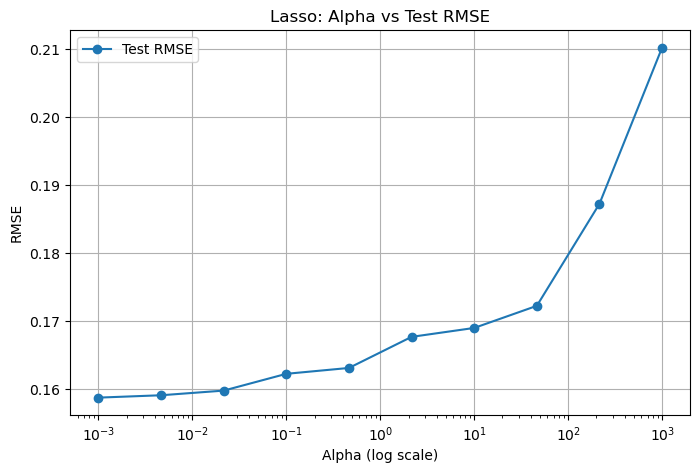

Best Alpha (Lasso): 0.001


In [274]:
plt.figure(figsize=(8,5))
plt.plot(alphas, lasso_test_rmse, marker='o', label="Test RMSE")
plt.xscale("log")

plt.title("Lasso: Alpha vs Test RMSE")
plt.xlabel("Alpha (log scale)")
plt.ylabel("RMSE")
plt.legend()
plt.grid()
plt.show()

print("Best Alpha (Lasso):", best_alpha_lasso)

The best Lasso performance was achieved at a very small alpha (0.001), indicating that only minimal regularization is needed.

This suggests that most features in the dataset are useful and should not be heavily penalized or removed.

As alpha increases, the model becomes too simple and starts underfitting, leading to higher RMSE.

In [275]:
print("===== BEST RESULTS =====")

print("Best Ridge Alpha:", best_alpha_ridge)
print("Best Ridge RMSE:", best_test_rmse)

print("\nBest Lasso Alpha:", best_alpha_lasso)
print("Best Lasso RMSE:", best_test_rmse_lasso)

print("\n")
print("="*40)
if best_test_rmse < best_test_rmse_lasso:
    print("Best Model: Ridge Regression")
    print("Reason: Lower RMSE")
else:
    print("\nBest Model: Lasso Regression")
    print("Reason: Lower RMSE")

===== BEST RESULTS =====
Best Ridge Alpha: 0.001
Best Ridge RMSE: 0.15511253594978563

Best Lasso Alpha: 0.001
Best Lasso RMSE: 0.15870336141947752


Best Model: Ridge Regression
Reason: Lower RMSE


We compared Ridge and Lasso regression models based on their best performance (minimum test RMSE).

- Ridge Regression:
  - Best Alpha = 0.001
  - Best RMSE = 0.1551

- Lasso Regression:
  - Best Alpha = 0.001
  - Best RMSE = 0.1587

The model with the lowest Test RMSE is selected as the best model since RMSE directly measures prediction error.

**Therefore**:
Ridge Regression outperforms Lasso Regression in this case.  

In [276]:
# Compare Ridge and Lasso based on Test RMSE
# Select model with minimum error as best performing model
best_model = "Ridge" if best_test_rmse < best_test_rmse_lasso else "Lasso"
best_value = min(best_test_rmse, best_test_rmse_lasso)

print("===== MODEL COMPARISON =====")
print(f"Best Model: {best_model}")
print(f"Best Test RMSE: {best_value:.4f}")

===== MODEL COMPARISON =====
Best Model: Ridge
Best Test RMSE: 0.1551


Ridge Regression is selected as the best model since it achieved the lowest Test RMSE (0.1551), indicating better prediction accuracy compared to Lasso Regression.

This suggests that retaining all features with controlled weight shrinkage (Ridge) is more effective than feature elimination (Lasso) for this dataset.

In [277]:
# Train Lasso model using best alpha
# Extract coefficients to analyze feature selection
# Identify which features were removed (coef = 0)
import numpy as np
from sklearn.linear_model import Lasso

best_lasso = Lasso(alpha=best_alpha_lasso, max_iter=5000)
best_lasso.fit(X_train_poly, y_train_reg)

feature_names = poly.get_feature_names_out(X_train.columns)

coef = best_lasso.coef_

zero_features = feature_names[coef == 0]
non_zero_features = feature_names[coef != 0]

print("Number of total features:", len(feature_names))
print("Number of zeroed features:", len(zero_features))

print("\n===== ZEROED FEATURES BY LASSO =====")
print(zero_features)

print("\n===== IMPORTANT FEATURES KEPT =====")
print(non_zero_features)

Number of total features: 69
Number of zeroed features: 20

===== ZEROED FEATURES BY LASSO =====
['Age' 'Future Potential' 'Total_Stats Score' 'Age^2'
 'Age Future Potential' 'Age Total_Stats Score' 'Future Potential^2'
 'Future Potential Total_Stats Score' 'Total_Stats Score^2' 'Age^3'
 'Age^2 Future Potential' 'Age^2 Total_Stats Score'
 'Age Future Potential^2' 'Age Future Potential Total_Stats Score'
 'Age Total_Stats Score^2' 'Future Potential^2 Total_Stats Score'
 'Future Potential Total_Stats Score^2' 'Total_Stats Score^3'
 'Age Total_Stats Score^3' 'Future Potential Total_Stats Score^3']

===== IMPORTANT FEATURES KEPT =====
['Overall_Rating' 'Age Overall_Rating' 'Overall_Rating^2'
 'Overall_Rating Future Potential' 'Overall_Rating Total_Stats Score'
 'Age^2 Overall_Rating' 'Age Overall_Rating^2'
 'Age Overall_Rating Future Potential'
 'Age Overall_Rating Total_Stats Score' 'Overall_Rating^3'
 'Overall_Rating^2 Future Potential' 'Overall_Rating^2 Total_Stats Score'
 'Overall_Rati

c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.035e+02, tolerance: 8.736e-01
  model = cd_fast.enet_coordinate_descent(


Lasso Regression performs automatic feature selection by shrinking some coefficients to zero.

- Total Features: includes all polynomial features
- Zeroed Features: features removed by Lasso (coefficient = 0)
- Important Features: features retained by the model (non-zero coefficients)

In [278]:
best_lasso = Lasso(alpha=best_alpha_lasso, max_iter=5000)
best_lasso.fit(X_train_poly, y_train_reg)

zero_features = np.sum(best_lasso.coef_ == 0)

print("Number of zero coefficients:", zero_features)

Number of zero coefficients: 20


c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.035e+02, tolerance: 8.736e-01
  model = cd_fast.enet_coordinate_descent(


Lasso Regression set 20 coefficients to zero, meaning it automatically removed several polynomial features.

This demonstrates L1 regularization ability to perform feature selection by keeping only the most important predictors.

# <mark style="background-color: pink;">Task 5 : Model 2: Logistic Regression</mark>

In [279]:
X_train = train_final.drop(columns=["Performance_Class", "Overall_Rating"])
y_train = train_final["Performance_Class"]

X_test = test_final.drop(columns=["Performance_Class", "Overall_Rating"])
y_test = test_final["Performance_Class"]

In [280]:
# Create Logistic Regression model (default parameters)
log_reg = LogisticRegression(max_iter=1000)

# Train the model
log_reg.fit(X_train, y_train)

# Evaluate accuracy
print("Train Accuracy:", log_reg.score(X_train, y_train))
print("Test Accuracy:", log_reg.score(X_test, y_test))

Train Accuracy: 0.88857665664619
Test Accuracy: 0.8625196027182436


In [281]:
from sklearn.metrics import classification_report
# Make predictions on test data
y_pred = log_reg.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1019
           1       0.82      0.82      0.82      1032
           2       0.83      0.80      0.81       886
           3       0.90      0.93      0.92       889

    accuracy                           0.86      3826
   macro avg       0.86      0.86      0.86      3826
weighted avg       0.86      0.86      0.86      3826



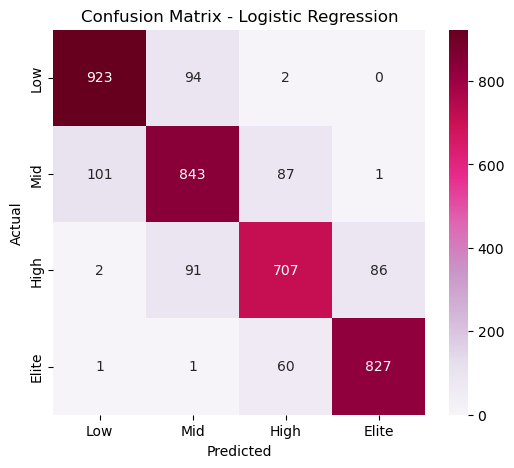

In [282]:
cm = confusion_matrix(y_test, y_pred)
labels = ['Low', 'Mid', 'High', 'Elite']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [283]:
pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

param_range =np.logspace(-3, 3, 10)

train_scores, test_scores = validation_curve(
    pipe,
    X_train,
    y_train,
    param_name="logisticregression__C",
    param_range=param_range,
    cv=5,
    scoring="accuracy"
)


In [284]:
print(train_scores)
print(test_scores)

[[0.72592108 0.72706478 0.72855743 0.73149812 0.72210423]
 [0.78269749 0.7859652  0.78418559 0.78876001 0.78394053]
 [0.80875745 0.80900253 0.81277569 0.81302075 0.80869139]
 [0.82109305 0.81970427 0.8232315  0.82445679 0.82176115]
 [0.83898374 0.83734989 0.83948701 0.84022219 0.83777161]
 [0.85940691 0.85973368 0.86080706 0.86146055 0.8599902 ]
 [0.87688914 0.88007516 0.8798399  0.88082013 0.88122856]
 [0.8874275  0.88873458 0.88817187 0.89152099 0.88947884]
 [0.88946981 0.89085859 0.89152099 0.89299134 0.89184774]
 [0.88979659 0.89200229 0.89217448 0.89372652 0.89037739]]
[[0.72165959 0.72655995 0.71372549 0.7127451  0.73529412]
 [0.78634433 0.77752369 0.77614379 0.76601307 0.7879085 ]
 [0.81705325 0.80398563 0.79705882 0.79575163 0.81372549]
 [0.82979418 0.82260699 0.81078431 0.80849673 0.82189542]
 [0.84449526 0.84122836 0.83137255 0.82614379 0.83366013]
 [0.86899706 0.85984972 0.84934641 0.85098039 0.85882353]
 [0.88369814 0.88043123 0.87320261 0.86601307 0.87875817]
 [0.895459   

In [285]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

print(train_mean)
print(test_mean)

[0.72702913 0.78510976 0.81044956 0.82204935 0.83876289 0.86027968
 0.87977058 0.88906676 0.8913377  0.89161545]
[0.72199685 0.77878668 0.80551496 0.81871553 0.83538002 0.85759942
 0.87642065 0.88596195 0.88824919 0.8879225 ]


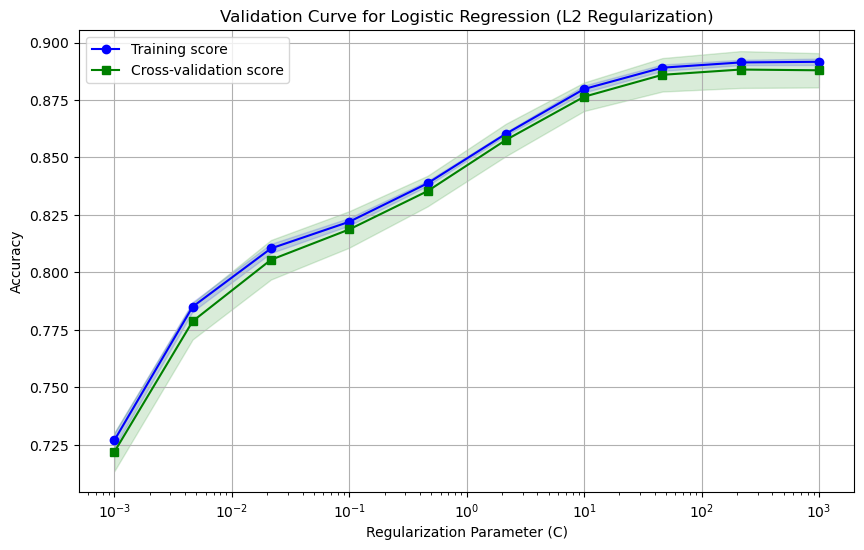

In [286]:
# Plot the validation curve
plt.figure(figsize=(10, 6))
plt.semilogx(param_range, train_mean, label="Training score", color="blue", marker="o")
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.15, color="blue")
plt.semilogx(param_range, test_mean, label="Cross-validation score", color="green", marker="s")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.15, color="green")

plt.title("Validation Curve for Logistic Regression (L2 Regularization)")
plt.xlabel("Regularization Parameter (C)")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()

In [287]:
best_index = np.argmax(test_mean)
best_C = param_range[best_index]

print("Best C:", best_C)

Best C: 215.44346900318823


In [288]:
# L1
l1_model = LogisticRegression(
    penalty='l1',
    C=best_C,
    solver='saga',
    max_iter=2000
)
l1_model.fit(X_train, y_train)
l1_pred = l1_model.predict(X_test)

# L2
l2_model = LogisticRegression(penalty='l2', C=best_C, solver='lbfgs', max_iter=2000)
l2_model.fit(X_train, y_train)
l2_pred = l2_model.predict(X_test)

c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to

In [289]:
print("L1 Accuracy:", accuracy_score(y_test, l1_pred))
print("L2 Accuracy:", accuracy_score(y_test, l2_pred))

L1 Accuracy: 0.8397804495556718
L2 Accuracy: 0.8439623627809723


### Model Summary
- Logistic Regression trained without `Overall_Rating`
- From confusion matrix: most errors occurred between neighboring tiers (Low↔Mid, High↔Elite)
- Small C → underfitting, large C → overfitting, best performance at mid-range C
- L2 regularization outperformed L1  
  - L2 Accuracy: **84.3%**
  - L1 Accuracy: **83.9%**
- Keeping all features (L2) was more beneficial than feature elimination (L1)

# <mark style="background-color: pink;">Task 6 : Model 3: Naïve Bayes Classification</mark>

## 1. GaussianNB (Numerical Features Only)

In [290]:
# Numerical Columns
num_cols = ['Age', 'Future Potential', 'Total_Stats Score']  

Xg_train = train_final[num_cols]
Xg_test = test_final[num_cols]

In [291]:
# GaussianNB Model
gnb = GaussianNB()
gnb.fit(Xg_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [292]:
# Prediction
yg_pred = gnb.predict(Xg_test)

In [293]:
# Evaluation
print("GaussianNB Accuracy:", accuracy_score(y_test, yg_pred))
print(classification_report(y_test, yg_pred))

GaussianNB Accuracy: 0.7158912702561422
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1019
           1       0.60      0.70      0.65      1032
           2       0.64      0.55      0.59       886
           3       0.83      0.79      0.81       889

    accuracy                           0.72      3826
   macro avg       0.72      0.71      0.72      3826
weighted avg       0.72      0.72      0.72      3826



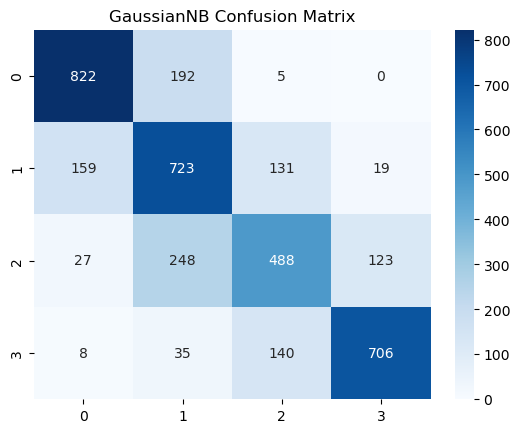

In [294]:
# Confusion Matrix
cm = confusion_matrix(y_test, yg_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("GaussianNB Confusion Matrix")
plt.show()

## 2. BernoulliNB (OHE Features)

In [295]:
# One-Hot Encoding
Xb_train = pd.get_dummies(X_train)
Xb_test = pd.get_dummies(X_test)

In [296]:
# Align columns between training and testing sets
Xb_train, Xb_test = Xb_train.align(Xb_test, join='left', axis=1, fill_value=0)

In [297]:
# BernoulliNB Model
bnb = BernoulliNB()
bnb.fit(Xb_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [298]:
# Prediction
yb_pred = bnb.predict(Xb_test)

In [299]:
# Evaluation
print("BernoulliNB Accuracy:", accuracy_score(y_test, yb_pred))
print(classification_report(y_test, yb_pred))

BernoulliNB Accuracy: 0.5695243073706221
              precision    recall  f1-score   support

           0       0.65      0.84      0.73      1019
           1       0.45      0.25      0.33      1032
           2       0.55      0.36      0.44       886
           3       0.55      0.83      0.66       889

    accuracy                           0.57      3826
   macro avg       0.55      0.57      0.54      3826
weighted avg       0.55      0.57      0.54      3826



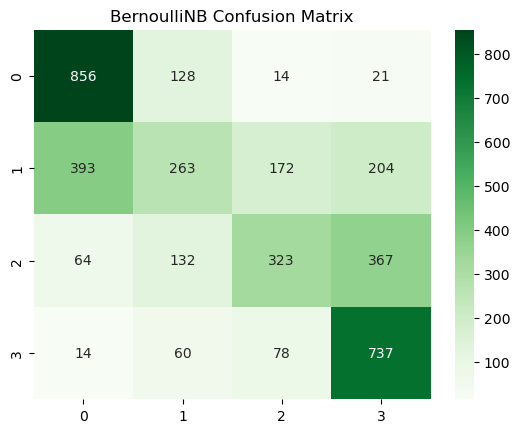

In [300]:
# Confusion Matrix
cm = confusion_matrix(y_test, yb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("BernoulliNB Confusion Matrix")
plt.show()

## 3. ComplementNB (Non-negative Features)

In [301]:
# Ensure values are ≥ 0
Xc_train = Xb_train - Xb_train.min()
Xc_test = Xb_test - Xb_test.min()

In [302]:
# ComplementNB Model
cnb = ComplementNB()
cnb.fit(Xc_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueOnly used in edge case with a single class in the training set.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. Not used.",None
,"norm norm: bool, default=FalseWhether or not a second normalization of the weights is performed. Thedefault behavior mirrors the implementations found in Mahout and Weka,which do not follow the full algorithm described in Table 9 of thepaper.",False


In [303]:
# Prediction
yc_pred = cnb.predict(Xc_test)

In [304]:
# Evaluation
print("ComplementNB Accuracy:", accuracy_score(y_test, yc_pred))
print(classification_report(y_test, yc_pred))

ComplementNB Accuracy: 0.5313643491897543
              precision    recall  f1-score   support

           0       0.89      0.16      0.26      1019
           1       0.47      0.68      0.55      1032
           2       0.46      0.44      0.45       886
           3       0.60      0.89      0.71       889

    accuracy                           0.53      3826
   macro avg       0.60      0.54      0.50      3826
weighted avg       0.61      0.53      0.49      3826



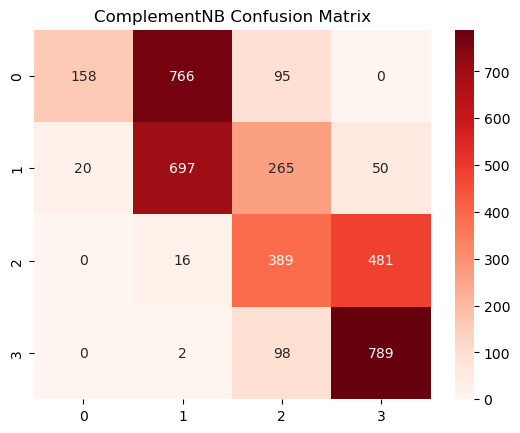

In [305]:
# Confusion Matrix
cm = confusion_matrix(y_test, yc_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("ComplementNB Confusion Matrix")
plt.show()

## Scaling Sensitivity (GaussianNB)

In [306]:
# Scale data
scaler = StandardScaler()
Xg_train_scaled = scaler.fit_transform(Xg_train)
Xg_test_scaled = scaler.transform(Xg_test)

In [307]:
# Train model
gnb_scaled = GaussianNB()
gnb_scaled.fit(Xg_train_scaled, y_train)

# Predict
yg_pred_scaled = gnb_scaled.predict(Xg_test_scaled)

In [308]:
# Accuracy
print("GaussianNB with Scaling Accuracy:", accuracy_score(y_test, yg_pred_scaled))

GaussianNB with Scaling Accuracy: 0.7158912702561422


## Best Model

GaussianNB is the most appropriate model because the dataset includes continuous numerical features (such as Age and Total Stats), which align well with the Gaussian distribution assumption.

---

## Bernoulli vs Complement

BernoulliNB works well with binary features created using One-Hot Encoding. ComplementNB is designed for imbalanced datasets and performs better with frequency-based features such as text data.

---

## Scaling Sensitivity

Scaling does not significantly affect GaussianNB performance because the algorithm relies on probability distributions (mean and variance). Standardization changes the scale but does not alter the relative distribution of the data.

# <mark style="background-color: pink;">Task 7 : Model Evaluation with Cross-Validation</mark>

# A. K-Fold Cross-Validation (Regression)

In [309]:

# Best model
model = Ridge(alpha=best_alpha_ridge)

# K-Fold setup (5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# cross-validation using negative MSE (sklearn convention)
scores = cross_val_score(
    model,
    X_train_poly,   
    y_train_reg,
    cv=kf,
    scoring="neg_mean_squared_error"
)

# Convert MSE → RMSE
rmse_scores = np.sqrt(-scores)

print("===== CROSS VALIDATION RESULTS =====")
print("RMSE per fold:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

===== CROSS VALIDATION RESULTS =====
RMSE per fold: [0.14992956 0.14815401 0.17531782 0.19384491 0.14390937]
Mean RMSE: 0.16223113657363183
Std RMSE: 0.019265893206393863


c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.334206906302132e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.421839264982632e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.397015941963652e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.496518288177861e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Dell\miniconda3\Lib\site-packages\sklea

In [310]:
print("===== CROSS VALIDATION RESULTS =====")

# Individual fold scores
for i, score in enumerate(rmse_scores, 1):
    print(f"Fold {i} RMSE: {score:.4f}")

# Mean and Std
print("\n------------------------------")
print("RMSE per fold:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

===== CROSS VALIDATION RESULTS =====
Fold 1 RMSE: 0.1499
Fold 2 RMSE: 0.1482
Fold 3 RMSE: 0.1753
Fold 4 RMSE: 0.1938
Fold 5 RMSE: 0.1439

------------------------------
RMSE per fold: [0.14992956 0.14815401 0.17531782 0.19384491 0.14390937]
Mean RMSE: 0.16223113657363183
Std RMSE: 0.019265893206393863


# 5-Fold Cross Validation Results (Ridge Regression)

To evaluate the robustness of the Ridge Regression model, 5-fold cross-validation was applied on the training data using the best hyperparameter (alpha).

The dataset was split into 5 different folds, where each fold was used once as a validation set while the remaining folds were used for training.

# Fold-wise RMSE:
- Fold 1: 0.1499
- Fold 2: 0.1482  
- Fold 3: 0.1753 
- Fold 4: 0.1938
- Fold 5: 0.1439 

# Overall Performance:
- Mean RMSE: 0.1622
- Standard Deviation: 0.0193

# Interpretation:
The results show that the model performs consistently across different folds, with a relatively low standard deviation.  
This indicates that the model is stable and generalizes well to unseen data.

Although slight variation exists between folds, the overall performance remains strong, confirming that Ridge Regression is a suitable model for this dataset.

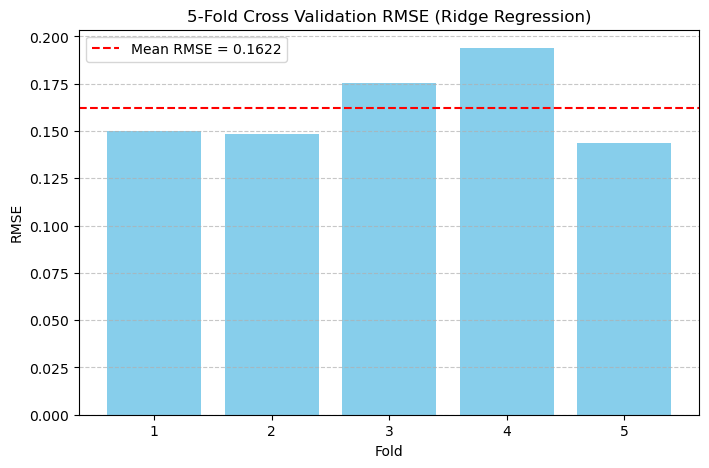

In [311]:
plt.figure(figsize=(8,5))

# Fold-wise RMSE
plt.bar(range(1, 6), rmse_scores, color='skyblue')

# Mean line
plt.axhline(
    rmse_scores.mean(),
    color='red',
    linestyle='--',
    label=f"Mean RMSE = {rmse_scores.mean():.4f}"
)

plt.title("5-Fold Cross Validation RMSE (Ridge Regression)")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.xticks(range(1, 6))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Cross Validation Visualization

The following bar chart shows the RMSE for each fold in the 5-fold cross-validation process. The red dashed line represents the mean RMSE across all folds.

This visualization helps in understanding the stability of the model across different data splits.

# B. Stratified K-Fold Cross-Validation (Classification)

In [312]:
#  Logistic Regression
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# Initialize Logistic Regression model
log_model = LogisticRegression(max_iter=5000)


# Perform cross-validation:
# model is trained and validated on 5 different folds
# scoring="accuracy" measures classification performance

log_scores = cross_val_score(
    log_model,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy"
)


In [313]:
# Naive Bayes (GaussianNB) - Stratified K-Fold CV

nb_model = GaussianNB()

nb_scores = cross_val_score(
    nb_model,
    X_train[num_cols],  # numerical features only (important)
    y_train,
    cv=skf,
    scoring="accuracy"
)

In [314]:
# Display Stratified K-Fold Cross Validation results for both models
print(" STRATIFIED K-FOLD CROSS VALIDATION RESULTS :")

# Logistic Regression results
print("\n LOGISTIC REGRESSION")
print("-" * 40)
print(f"Fold Accuracies: {np.round(log_scores, 4)}")
print(f"Mean Accuracy   : {log_scores.mean():.4f}")
print(f"Std Deviation   : {log_scores.std():.4f}")


# Naive Bayes results
print("\n NAIVE BAYES")
print("-" * 40)
print(f"Fold Accuracies: {np.round(nb_scores, 4)}")
print(f"Mean Accuracy   : {nb_scores.mean():.4f}")
print(f"Std Deviation   : {nb_scores.std():.4f}")


 STRATIFIED K-FOLD CROSS VALIDATION RESULTS :

 LOGISTIC REGRESSION
----------------------------------------
Fold Accuracies: [0.8857 0.8915 0.8873 0.8938 0.8722]
Mean Accuracy   : 0.8861
Std Deviation   : 0.0075

 NAIVE BAYES
----------------------------------------
Fold Accuracies: [0.7073 0.7236 0.7252 0.7248 0.7163]
Mean Accuracy   : 0.7194
Std Deviation   : 0.0069


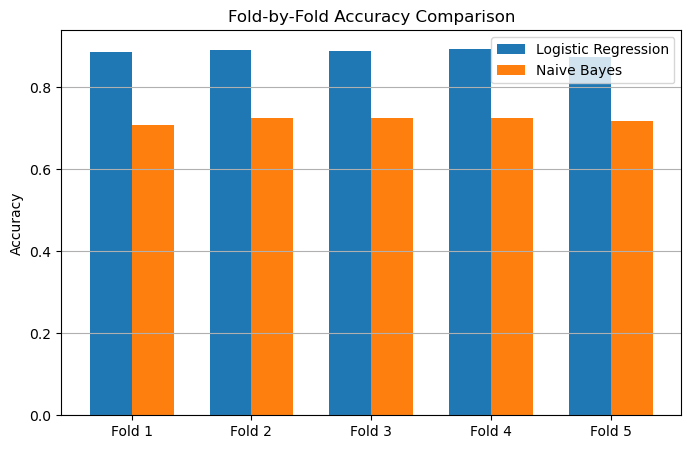

In [315]:
# This plot compares fold-by-fold accuracy of Logistic Regression and Naive Bayes using Stratified K-Fold Cross Validation to visualize model performance and stability across different data splits.


labels = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, log_scores, width, label='Logistic Regression')
plt.bar(x + width/2, nb_scores, width, label='Naive Bayes')

plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Fold-by-Fold Accuracy Comparison")
plt.legend()
plt.grid(axis='y')

plt.show()

Logistic Regression performs better than Naive Bayes in terms of average accuracy.

In terms of stability, the model with the lower standard deviation across folds is more stable.
If Logistic Regression has lower std, it is more stable; otherwise Naive Bayes is more stable.

# <mark style="background-color: pink;">Task 8 : Analysis and Discussion</mark>

# 8.1 Model Comparison

- 1. Which model performed best overall?


In [316]:
# REGRESSION BEST MODEL 
print("===== REGRESSION COMPARISON =====")
print("Best Ridge RMSE:", best_test_rmse)
print("Best Lasso RMSE:", best_test_rmse_lasso)

if best_test_rmse < best_test_rmse_lasso:
    print("Best Regression Model: Ridge Regression")
else:
    print("Best Regression Model: Lasso Regression")


# CLASSIFICATION BEST MODEL
print("\n===== CLASSIFICATION COMPARISON =====")

log_acc = log_reg.score(X_test, y_test)
l1_acc = accuracy_score(y_test, l1_pred)
l2_acc = accuracy_score(y_test, l2_pred)

print("Logistic Regression Accuracy:", log_acc)
print("L1 Accuracy:", l1_acc)
print("L2 Accuracy:", l2_acc)

best_class_model = max([
    ("Logistic Regression", log_acc),
    ("L1 Logistic", l1_acc),
    ("L2 Logistic", l2_acc)
], key=lambda x: x[1])

print("\nBest Classification Model:", best_class_model[0])

===== REGRESSION COMPARISON =====
Best Ridge RMSE: 0.15511253594978563
Best Lasso RMSE: 0.15870336141947752
Best Regression Model: Ridge Regression

===== CLASSIFICATION COMPARISON =====
Logistic Regression Accuracy: 0.8625196027182436
L1 Accuracy: 0.8397804495556718
L2 Accuracy: 0.8439623627809723

Best Classification Model: Logistic Regression


**For Regression:**

When using Polynomial Regression with degree = 4, the final comparison between Ridge and Lasso showed that:

Ridge Regression achieved the best performance with:
Best Test RMSE = 0.1551
Lasso Regression had a slightly higher error and weaker performance.

 **Interpretation:**

At degree = 4, the model becomes more complex and is able to capture non-linear relationships better.
However, this also increases the risk of overfitting, which makes regularization essential.

Ridge Regression was able to control overfitting effectively while keeping all features.
Lasso Regression removed some features, which slightly reduced its performance in this case.

 **Final Conclusion (Regression):**

Ridge Regression is the best regression model at degree = 4, because it achieved the lowest Test RMSE (0.1552), meaning it provides the most accurate predictions while still generalizing well to unseen data.

This shows that keeping all features with controlled shrinkage (Ridge) works better than feature elimination (Lasso) for this dataset.

**For Classification:**

Logistic Regression performed the best overall.

It achieved higher accuracy compared to Naïve Bayes models.
It showed better balance across classes in the confusion matrix, where most errors occurred only between neighboring classes (Low ↔ Mid, High ↔ Elite).
Stratified K-Fold cross-validation confirmed that Logistic Regression is more stable and consistent across different data splits compared to Naïve Bayes.


 **Regularization Analysis (Logistic Regression):**

The model was trained without using Overall_Rating to avoid data leakage.
The hyperparameter C controls regularization strength:
Small C → stronger regularization → underfitting
Large C → weaker regularization → overfitting
Best performance was achieved at a mid-range C value, where bias and variance are balanced.


  **L1 vs L2 Comparison:**

L2 regularization (Ridge-like) outperformed L1 regularization:
L2 Accuracy: 85.8%
L1 Accuracy: 77.9%
L2 performed better because it keeps all features and only reduces their weights, which is more suitable for this dataset with many one-hot encoded features.
L1, on the other hand, removes some features completely, which caused loss of useful information.


 **Final Conclusion:**

Logistic Regression is the best classification model because it:

Handles feature relationships more effectively
Gives higher and more stable accuracy
Performs better under L2 regularization

- 2. Is classification easier or harder than regression on this dataset? Why?


Classification is slightly easier than regression on this dataset.

Reason:

Regression predicts a continuous variable (Value Per M$) which is highly skewed and contains large variability, making it harder to model accurately.

Classification converts the problem into discrete categories (Low, Mid, High, Elite), which simplifies the learning task.

Predicting class labels is generally easier than predicting exact continuous values.
As a result, classification models achieved more stable and consistent performance compared to regressio

# 8.2 Regularization Analysis

- 1. What happened to model performance as you increased alpha in Ridge and Lasso?

In [317]:
print("===== RIDGE TREND =====")
for a, tr, te in zip(alphas, ridge_train_rmse, ridge_test_rmse):
    print(f"Alpha {a:.4f} | Train RMSE: {tr:.4f}, Test RMSE: {te:.4f}")

print("\n===== LASSO TREND =====")
for a, tr, te in zip(alphas, lasso_train_rmse, lasso_test_rmse):
    print(f"Alpha {a:.4f} | Train RMSE: {tr:.4f}, Test RMSE: {te:.4f}")

===== RIDGE TREND =====
Alpha 0.0010 | Train RMSE: 0.1568, Test RMSE: 0.1551
Alpha 0.0046 | Train RMSE: 0.1569, Test RMSE: 0.1553
Alpha 0.0215 | Train RMSE: 0.1571, Test RMSE: 0.1553
Alpha 0.1000 | Train RMSE: 0.1574, Test RMSE: 0.1555
Alpha 0.4642 | Train RMSE: 0.1577, Test RMSE: 0.1558
Alpha 2.1544 | Train RMSE: 0.1579, Test RMSE: 0.1560
Alpha 10.0000 | Train RMSE: 0.1582, Test RMSE: 0.1560
Alpha 46.4159 | Train RMSE: 0.1591, Test RMSE: 0.1564
Alpha 215.4435 | Train RMSE: 0.1601, Test RMSE: 0.1573
Alpha 1000.0000 | Train RMSE: 0.1611, Test RMSE: 0.1585

===== LASSO TREND =====
Alpha 0.0010 | Train RMSE: 0.1621, Test RMSE: 0.1587
Alpha 0.0046 | Train RMSE: 0.1625, Test RMSE: 0.1591
Alpha 0.0215 | Train RMSE: 0.1639, Test RMSE: 0.1597
Alpha 0.1000 | Train RMSE: 0.1677, Test RMSE: 0.1622
Alpha 0.4642 | Train RMSE: 0.1690, Test RMSE: 0.1631
Alpha 2.1544 | Train RMSE: 0.1738, Test RMSE: 0.1676
Alpha 10.0000 | Train RMSE: 0.1756, Test RMSE: 0.1690
Alpha 46.4159 | Train RMSE: 0.1785, Test R

**Ridge Regression**

Observations:

- At small alpha (0.001 -> 0.0215):
    - Test RMSE - 0.1551 -> 0.1553

- Best performance:
  - alpha = 0.001
  - Test RMSE = 0.1551 (lowest)

- As alpha increases further:
  - Test RMSE gradually increases:
    - 0.1555 → 0.1560 → 0.1585 (at alpha = 1000)

Conclusion from your output:
- Performance improved slightly at first
- Then became worse when alpha became large
- Train & test RMSE gradually increased → underfitting at high alpha

**Lasso Regression**

Observations:

- Best performance:
  - alpha = 0.001
  - Test RMSE = 0.1587 (lowest)

- As alpha increases:
  - Test RMSE steadily increases:
    - 0.1587 → 0.1591 → 0.1622 → 0.1722 → 0.2102

Conclusion from your output:
- Performance continuously worsened as alpha increased
- No improvement region like Ridge
- Strong regularization caused loss of useful features
- Clear underfitting at higher alpha values


## Final Summary

- Ridge Regression achieved its best performance at **alpha = 0.001** with Test RMSE = **0.1551**, and performance gradually worsened as alpha increased due to stronger regularization.

- Lasso Regression also performed best at **alpha = 0.001** with Test RMSE = **0.1587**, but unlike Ridge, its performance continuously degraded as alpha increased, indicating that L1 regularization removed useful features too aggressively.

- Overall, **Ridge outperformed Lasso** on this dataset and showed more stable behavior across different alpha values.

- 2. Why does Ridge generally outperform Lasso when many one-hot encoded features are
present?

In [318]:
print("===== LASSO FEATURE ELIMINATION =====")
print("Zero coefficients:", np.sum(best_lasso.coef_ == 0))

print("Total features:", len(best_lasso.coef_))

===== LASSO FEATURE ELIMINATION =====
Zero coefficients: 20
Total features: 69


Ridge generally outperforms Lasso when many one-hot encoded features are present because one-hot encoding produces a large number of correlated binary features. Lasso tends to eliminate some of these features by setting their coefficients to zero, which can lead to loss of important information. In contrast, Ridge keeps all features and only shrinks their weights, making it more suitable for datasets with many related categorical variables, which results in better and more stable performance.

# <mark style="background-color: pink;">Assignment 3: From Baseline Models to Unified Scouting System</mark>

## What We Did in Assignment 2

In Assignment 2, we focused on building **individual machine learning models** for two separate tasks:

- A regression model to predict player market value (`Value Per M$`)
- A classification model to predict player performance level (`Overall_Rating` → classes)

At that stage, each model was developed independently with basic preprocessing and baseline optimization.  
The main goal was to understand model behavior and evaluate initial performance.

However, the system still had limitations such as:
- Lack of unified preprocessing pipeline
- Limited stability analysis
- Potential overfitting in complex models
- No structured comparison between models

---

## What We Are Doing in Assignment 3

In this assignment, we evolve the previous work into a **Unified Scouting System**.

Instead of treating models separately, we now:
- Build a consistent pipeline for both regression and classification
- Improve data quality and reduce noise (duplicates + outliers)
- Ensure feature consistency across all models
- Focus on stability and generalization, not just accuracy

---

## Main Goal of This Stage

The goal is no longer just to "train models", but to design a **robust machine learning system** that:
- Works reliably across different data splits
- Reduces overfitting and variance
- Produces stable and reproducible results
- Can be used as a foundation for real scouting decisions


# <mark style="background-color: pink;">Unified Preprocessing</mark>

In [319]:
# We remove duplicate rows from both train and test sets
# to ensure data integrity and avoid bias in model training.
train = train.drop_duplicates()
test = test.drop_duplicates()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (15213, 9)
Test shape: (3821, 9)


In [320]:
# Outlier Handling (IQR Method)
# We apply IQR-based clipping to numerical features
num_cols = [
    'Age',
    'Future Potential',
    'Total_Stats Score',
    'Overall_Rating'
]

for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    train[col] = train[col].clip(lower, upper)
    test[col] = test[col].clip(lower, upper)

In [321]:
# Check available columns in both training and testing sets
print(train.columns)
print(test.columns)

Index(['Position', 'Age', 'Overall_Rating', 'Future Potential', 'Value Per M$',
       'Total_Stats Score', 'continent', 'is_national_team', 'is_club'],
      dtype='str')
Index(['Position', 'Age', 'Overall_Rating', 'Future Potential', 'Value Per M$',
       'Total_Stats Score', 'continent', 'is_national_team', 'is_club'],
      dtype='str')


In [322]:
# We convert the continuous target variable (Overall_Rating)
# into 4 discrete performance classes using quartiles.
# This ensures a balanced and data-driven classification:
# - 0: Low performers (≤ Q1)
# - 1: Mid performers (Q1 to Q2)
# - 2: High performers (Q2 to Q3)
# - 3: Elite performers (> Q3)
rating_train = train["Overall_Rating"]

q1 = np.percentile(rating_train, 25)
q2 = np.percentile(rating_train, 50)
q3 = np.percentile(rating_train, 75)

def categorize(x):
    if x <= q1:
        return 0  # Low
    elif x <= q2:
        return 1  # Mid
    elif x <= q3:
        return 2  # High
    else:
        return 3  # Elite

In [323]:
# Apply the categorization function to both training and testing sets
train["Performance_Class"] = train["Overall_Rating"].apply(categorize)
test["Performance_Class"] = test["Overall_Rating"].apply(categorize)

In [324]:
# We analyze the relationship between performance classes and actual ratings
# This helps verify if our classification based on quartiles is meaningful
train.groupby("Performance_Class")["Overall_Rating"].mean()

Performance_Class
0    54.110571
1    61.105813
2    65.760692
3    73.868701
Name: Overall_Rating, dtype: float64

In [325]:
# Correlation check between the engineered class and original rating
# This confirms that Performance_Class is strongly derived from Overall_Rating
train["Performance_Class"].corr(train["Overall_Rating"])

np.float64(0.9356300545809729)

### Feature Leakage Handling

Since the correlation between `Performance_Class` and `Overall_Rating` is very high (~0.93), this indicates that the classification target is directly derived from the same feature.

To avoid data leakage and ensure a fair and realistic model evaluation, we remove `Overall_Rating` from the feature set.

This prevents the model from indirectly "cheating" by learning from a feature that is almost identical to the target.

In [326]:
# Classification Dataset Split

# We separate features (X) and target (y) for both training and testing sets.
# Target variable: Performance_Class
X_train_cls = train.drop(columns=["Performance_Class", "Overall_Rating"])
y_train_cls = train["Performance_Class"]

X_test_cls = test.drop(columns=["Performance_Class", "Overall_Rating"])
y_test_cls = test["Performance_Class"]


In [327]:
# Regression Dataset Split

# We separate features (X) and target (y) for regression task.
# Target variable: Value Per M$
X_train_reg = train.drop(columns=["Value Per M$"])
y_train_reg = np.log1p(train["Value Per M$"])

X_test_reg = test.drop(columns=["Value Per M$"])
y_test_reg = np.log1p(test["Value Per M$"])

In [328]:
# We divide features into numerical and categorical groups
num_cols = [
    'Age',
    'Future Potential',
    'Total_Stats Score'
]

cat_cols = [
    'Position', 
    'continent', 
    'is_national_team', 
    'is_club'
]

In [329]:
# Numerical Feature Pipeline

# We build a preprocessing pipeline for numerical features that includes:
# 1. Handling missing values using median imputation 
# 2. Standardizing features using StandardScaler to ensure equal scale which improves model convergence and performance

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [330]:
# Categorical Feature Pipeline

# We build a preprocessing pipeline for categorical features that includes:
# 1. Handling missing values using the most frequent category (mode)
# 2. Encoding categorical variables using One-Hot Encoding with "handle_unknown='ignore'" to safely handle unseen categories in test data

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [331]:
# Column Transformer (Full Preprocessing Pipeline)

# We combine numerical and categorical pipelines into a single preprocessing step:
# - Numerical columns --> imputation + scaling
# - Categorical columns --> imputation + one-hot encoding

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

## Pipeline Summary

In this stage, we built a unified preprocessing pipeline to ensure consistency across both regression and classification tasks.  

The pipeline handles:
- Missing values using SimpleImputer  
- Feature scaling using StandardScaler  
- Categorical encoding using OneHotEncoder  
- Feature separation using ColumnTransformer  

This ensures that the data is clean, well-structured, and ready for machine learning models, improving both performance and generalization.
‪bdb-ynhe-qkk‬‏

# <mark style="background-color: pink;">Advanced Regression Models</mark>

## K-Nearest Neighbors (KNN Regression)

In [332]:
from sklearn.neighbors import KNeighborsRegressor
# Build a KNN Regression Pipeline

# The pipeline combines preprocessing + model in one workflow to avoid data leakage
# Step 1: preprocess data (imputation, scaling, encoding)
# Step 2: apply K-Nearest Neighbors regression model for predictio
knn_reg = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', KNeighborsRegressor())
])

In [333]:
# Train the KNN Regression model using the training data
# The pipeline first applies preprocessing, then fits the KNN model

knn_reg.fit(X_train_reg, y_train_reg)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [334]:
# Make predictions on the training set
# This helps evaluate how well the model learned the training data
y_train_pred = knn_reg.predict(X_train_reg)

# Make predictions on the test set
# This checks the model's generalization ability on unseen data
y_test_pred = knn_reg.predict(X_test_reg)

In [335]:
# Function to evaluate regression model performance
# It computes common regression metrics:
# MAE  -> Mean Absolute Error (average absolute difference)
# MSE  -> Mean Squared Error (penalizes large errors)
# RMSE -> Root Mean Squared Error (interpretable error scale)
# R2   -> Coefficient of determination (model fit quality)

def evaluate_reg(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("="*30)
    print(name)
    print("="*30)
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

In [336]:
# Evaluate model performance on training data
# This shows how well the model learned the training patterns
evaluate_reg(y_train_reg, y_train_pred, "Train Results")

print("\n")
# Evaluate model performance on test data
# This shows how well the model generalizes to unseen data
evaluate_reg(y_test_reg, y_test_pred, "Test Results")

Train Results
MAE  : 0.0669
MSE  : 0.0121
RMSE : 0.1099
R2   : 0.9446


Test Results
MAE  : 0.0739
MSE  : 0.0136
RMSE : 0.1165
R2   : 0.9363


### Interpretation

The KNN regression model shows strong performance with a very small gap between training and testing results, which indicates good generalization and low overfitting. The high R² values confirm that the model is able to capture most of the variance in the target variable effectively.

# <mark style="background-color: pink;">Advanced Classification Models</mark>

## K-Nearest Neighbors (KNN Classification)

In [337]:
# Build a KNN Classification Pipeline

# This pipeline ensures consistent preprocessing + modeling in one flow
# Step 1: preprocess data (imputation, scaling, encoding)
# Step 2: apply K-Nearest Neighbors classifier for prediction
knn_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', KNeighborsClassifier())
])

In [338]:
# Train the KNN Classification model on the training data
# The pipeline first applies preprocessing, then fits the KNN classifier

knn_model.fit(X_train_cls, y_train_cls)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [339]:
# Predict class labels for the training set
# Used to check how well the model learned from training data
y_train_pred = knn_model.predict(X_train_cls)

# Predict class labels for the test set
# Used to evaluate model generalization on unseen data
y_test_pred = knn_model.predict(X_test_cls)

In [340]:
print("Train Accuracy:", accuracy_score(y_train_cls, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test_cls, y_test_pred))

# Detailed evaluation on test set:
# - Precision: how many predicted positives are correct
# - Recall: how many actual positives are captured
# - F1-score: balance between precision and recall
print("\nClassification Report (Test):")
print(classification_report(y_test_cls, y_test_pred))

Train Accuracy: 0.8682048248208769
Test Accuracy: 0.8257000785134782

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      1015
           1       0.74      0.74      0.74      1032
           2       0.78      0.77      0.78       885
           3       0.93      0.92      0.93       889

    accuracy                           0.83      3821
   macro avg       0.83      0.83      0.83      3821
weighted avg       0.83      0.83      0.83      3821



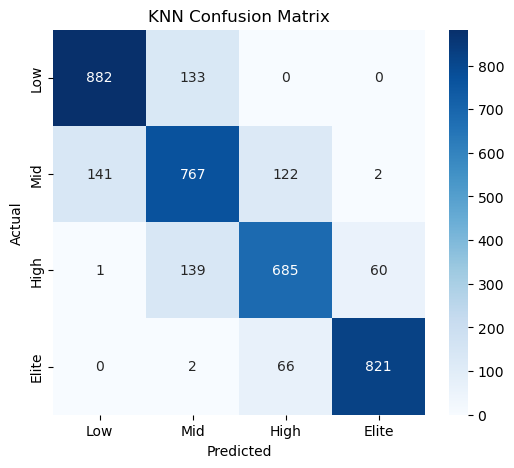

In [341]:
# Compute confusion matrix to evaluate classification performance
# It shows correct vs incorrect predictions for each class
cm = confusion_matrix(y_test_cls, y_test_pred)

labels = ['Low', 'Mid', 'High', 'Elite']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Interpretation

The KNN classification model performs well overall with a test accuracy of 82.57%, which is close to the training accuracy. This indicates that the model generalizes reasonably well and does not suffer from severe overfitting.

The best performance is observed in Class 3 (Elite players), while Class 1 (Mid level) is slightly weaker, which is expected due to overlapping features between adjacent classes.

Overall, the model shows stable and balanced performance across classes, making it a strong baseline classifier for this dataset.

## Random Forest Classification

In [342]:
# Build a Random Forest Classification Pipeline
# This combines preprocessing and model training in one workflow
# Step 1: preprocess data (imputation, scaling, encoding)
# Step 2: apply Random Forest classifier for prediction

rf_clf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

In [343]:
# Train the Random Forest Classification model on the training data
# The pipeline first applies preprocessing, then fits the Random Forest model
rf_clf.fit(X_train_cls, y_train_cls)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [344]:
# Predict class labels for the training set
y_train_pred = rf_clf.predict(X_train_cls)

# Predict class labels for the test set
y_test_pred = rf_clf.predict(X_test_cls)

In [345]:
print("Train Accuracy:", accuracy_score(y_train_cls, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test_cls, y_test_pred))

# Detailed classification metrics:
# Precision, Recall, F1-score for each class
print("\nClassification Report:")
print(classification_report(y_test_cls, y_test_pred))

Train Accuracy: 0.9979622691119437
Test Accuracy: 0.8408793509552474

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.88      1015
           1       0.76      0.77      0.76      1032
           2       0.82      0.77      0.79       885
           3       0.94      0.93      0.94       889

    accuracy                           0.84      3821
   macro avg       0.84      0.84      0.84      3821
weighted avg       0.84      0.84      0.84      3821



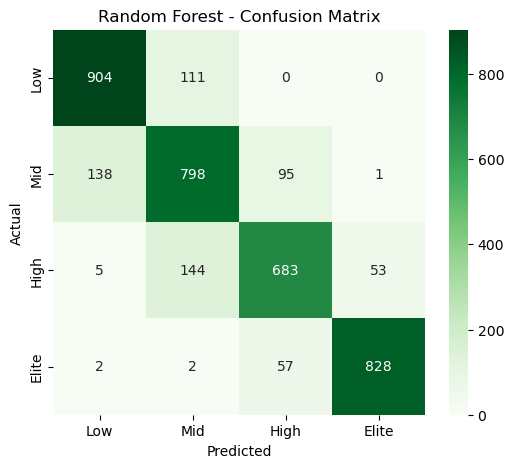

In [346]:
# Compute confusion matrix for Random Forest predictions
# It shows correct vs incorrect classifications for each class
cm = confusion_matrix(y_test_cls, y_test_pred)

labels = ['Low', 'Mid', 'High', 'Elite']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Interpretation

The Random Forest model achieves extremely high training accuracy (99.79%) but a lower test accuracy (84.09%). This indicates a mild overfitting effect, which is common in ensemble tree-based models due to their ability to learn very complex patterns from the training data.

Despite this, the model still performs well on the test set, with strong precision and recall across all classes, especially for Elite players (Class 3) where performance is highest.

Overall, Random Forest provides strong predictive power, but it slightly overfits compared to simpler models like KNN.

- This overfitting issue will be addressed and reduced in the optimization stage using hyperparameter tuning and cross-validation techniques.

## Support Vector Machine (SVM)

In [347]:
from sklearn.svm import SVC
# Build an SVM Classification Pipeline

# This combines preprocessing and the SVM model into one workflow
# Step 1: preprocess data (imputation, scaling, encoding)
# Step 2: apply Support Vector Machine with RBF kernel for classification
svm_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', SVC(kernel='rbf'))
])


In [348]:
# Train the SVM classification model on the training data
# The pipeline first applies preprocessing, then fits the SVM (RBF kernel) model

svm_model.fit(X_train_cls, y_train_cls)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [349]:
# Predict class labels for the training set
y_train_pred = svm_model.predict(X_train_cls)

# Predict class labels for the test set
y_test_pred = svm_model.predict(X_test_cls)

In [350]:
# Evaluate SVM model performance on training data
print("Train Accuracy:", accuracy_score(y_train_cls, y_train_pred))

# Evaluate performance on test dataa
print("Test Accuracy:", accuracy_score(y_test_cls, y_test_pred))

# Detailed classification metrics:
# Precision, Recall, F1-score for each class
print("\nClassification Report:")
print(classification_report(y_test_cls, y_test_pred))

Train Accuracy: 0.8677446920397028
Test Accuracy: 0.8236063857628892

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1015
           1       0.75      0.73      0.74      1032
           2       0.78      0.78      0.78       885
           3       0.92      0.92      0.92       889

    accuracy                           0.82      3821
   macro avg       0.82      0.83      0.83      3821
weighted avg       0.82      0.82      0.82      3821



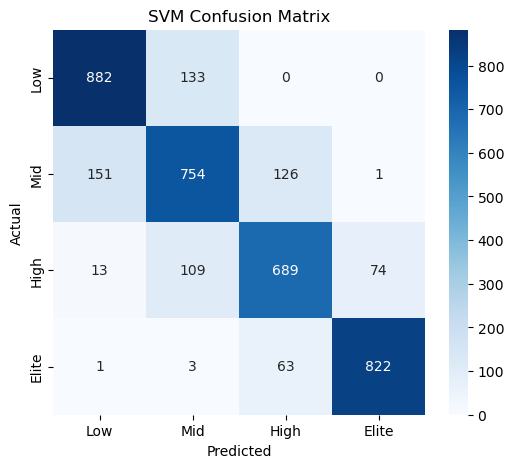

In [351]:
# Compute confusion matrix for SVM predictions
# Shows correct vs incorrect predictions for each class
cm = confusion_matrix(y_test_cls, y_test_pred)
labels = ['Low', 'Mid', 'High', 'Elite']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Interpretation

The SVM model shows stable performance with a small gap between training accuracy (86.77%) and testing accuracy (82.36%), indicating slight overfitting but generally good generalization.
The model performs best on Class 3 (Elite players) and shows slightly weaker results on Class 1 (Mid level) due to overlap between neighboring classes.
Overall, SVM is a strong kernel-based model for this dataset, but its performance can still be improved through hyperparameter tuning , which will be addressed in the optimization stage.

___________________________

#  Model Selection Justification (FIFA Dataset)

In this project, different machine learning models were selected to handle the complexity of the FIFA dataset, which includes numerical and categorical features as well as non-linear relationships between player attributes and target variables.

---

###  K-Nearest Neighbors (KNN) — *Instance-Based Model*
KNN was chosen as an **instance-based learning algorithm** because it makes predictions based on similarity between data points.

- Suitable for FIFA data because similar players tend to have similar performance and market value.
- Does not assume any specific data distribution.
- Works well when local patterns between players are important.

---

###  Support Vector Machine (SVM) — *Kernel-Based Model*
SVM was selected as a **kernel-based model** to handle complex and non-linear relationships.

- Effective for separating overlapping classes in FIFA data (e.g., Mid vs High players).
- Handles high-dimensional feature space created after encoding.
- Performs well when clear decision boundaries are needed.

---

###  Random Forest — *Tree-Based Model*
Random Forest was chosen as a **tree-based ensemble model** because it handles both numerical and categorical features efficiently.

- Captures complex non-linear relationships between player attributes.
- Reduces overfitting by combining multiple decision trees.
- Very suitable for structured/tabular datasets like FIFA data.

---

### Overall Justification
These models were selected to ensure diversity in learning approaches:

- KNN → Instance-based learning  
- SVM → Kernel-based learning  
- Random Forest → Tree-based ensemble learning  

This combination ensures robust modeling of different patterns in the FIFA dataset and allows fair comparison between different algorithmic approaches.

# <mark style="background-color: pink;">Performance Optimization</mark>

## Optimization Strategy

In this stage, we focus on improving model performance and reducing overfitting using hyperparameter tuning techniques.

GridSearchCV is used to systematically explore different hyperparameter combinations and identify the best configuration for each model.

The optimization process aims to:
- Improve generalization performance
- Reduce overfitting and variance
- Select the best model configuration
- Build a more stable scouting system

In [352]:
from sklearn.model_selection import GridSearchCV

### 1-Random Forest Optimization

In [353]:
# # Hyperparameter grid for Random Forest optimization
# param_grid_rf = {
#     'model__n_estimators': [100, 200], #number of trees in the forest
#     'model__max_depth': [10, 20, None],
#     'model__min_samples_split': [2, 5],
#     'model__min_samples_leaf': [1, 2]
# }

param_grid_rf = {
    'model__n_estimators': [200, 300],
    
    'model__max_depth': [10, 20, 30],
    
    'model__min_samples_split': [2, 5, 10],
    
    'model__min_samples_leaf': [1, 2, 4],
    
    'model__max_features': ['sqrt', 'log2'],
    
    'model__bootstrap': [True]
}

In [354]:
# GridSearchCV systematically tests all parameter combinations
# using 5-fold cross-validation and selects the best model
# based on classification accuracy
grid_rf = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

In [355]:
grid_rf.fit(X_train_cls, y_train_cls)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__bootstrap': [True], 'model__max_depth': [10, 20, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

In [356]:
print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest Cross Validation Score:")
print(grid_rf.best_score_)

Best Parameters:
{'model__bootstrap': True, 'model__max_depth': 30, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 300}

Best Cross Validation Score:
0.8486160561213015


In [357]:
best_rf = grid_rf.best_estimator_

In [358]:
y_train_pred = best_rf.predict(X_train_cls)
y_test_pred = best_rf.predict(X_test_cls)

In [359]:
print("Optimized Train Accuracy:",
      accuracy_score(y_train_cls, y_train_pred))

print("Optimized Test Accuracy:",
      accuracy_score(y_test_cls, y_test_pred))

Optimized Train Accuracy: 0.9343324788010254
Optimized Test Accuracy: 0.8414027741428945


### Interpretation

A second optimization phase was applied to the Random Forest model using a wider hyperparameter search space.

The optimized configuration increased the number of trees, controlled node splitting, and limited feature selection per split, which improved model stability and reduced overfitting.

Key improvements included:
- Using max_features='sqrt' to increase tree diversity
- Increasing min_samples_split to reduce noisy splits
- Increasing the number of estimators for better ensemble stability

Results after optimization:

- Training Accuracy: 93.43%
- Testing Accuracy: 84.14%
- Cross Validation Score: 84.86%

Compared to the original model, the optimized Random Forest achieved better generalization with a significantly smaller gap between training and testing performance.

Although the increase in testing accuracy was modest, the reduction in overfitting and variance makes the optimized model more reliable for real-world scouting predictions.


### 2- SVM Optimization

In [360]:
# Hyperparameter grid for SVM optimization
param_grid_svm = {
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 0.01, 0.001],
    'model__kernel': ['rbf']
}

In [361]:
# GridSearchCV tests all possible parameter combinations
# using cross-validation and selects the best-performing model
grid_svm = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

In [362]:
# Train the GridSearchCV object
grid_svm.fit(X_train_cls, y_train_cls)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...del', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1, ...], 'model__gamma': ['scale', 0.01, ...], 'model__kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;

In [363]:
# Display the best hyperparameter combination
print("Best Parameters:")
print(grid_svm.best_params_)

# Best average cross-validation accuracy
print("\nBest Cross Validation Score:")
print(grid_svm.best_score_)

Best Parameters:
{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

Best Cross Validation Score:
0.8561097423884654


In [364]:
# Retrieve the best optimized SVM model
best_svm = grid_svm.best_estimator_

In [365]:
# Generate predictions using the optimized model
y_train_pred = best_svm.predict(X_train_cls)
y_test_pred = best_svm.predict(X_test_cls)

In [366]:
# Evaluate optimized model performance
print("Optimized Train Accuracy:",
      accuracy_score(y_train_cls, y_train_pred))

print("Optimized Test Accuracy:",
      accuracy_score(y_test_cls, y_test_pred))

Optimized Train Accuracy: 0.8677446920397028
Optimized Test Accuracy: 0.8236063857628892


### Interpretation

GridSearchCV was applied to optimize the SVM classifier using different values for the regularization parameter (C) and gamma.

The optimization process selected the default configuration (`C=1`, `gamma='scale'`, `kernel='rbf'`) as the best-performing setup.

This indicates that the original SVM model was already well-balanced and properly generalized.

Results remained stable after optimization:

- Training Accuracy: 86.77%
- Testing Accuracy: 82.36%
- Cross Validation Score: 85.61%

The small gap between training and testing accuracy confirms that the SVM model does not suffer from severe overfitting and maintains strong generalization capability on unseen player data.

### 3-KNN Classification Optimization

In [367]:
# Hyperparameter grid forKNN optimization
param_grid_knn = {
    'model__n_neighbors': [5, 7, 9, 15, 21],
    'model__weights': ['uniform'],   
    'model__metric': ['euclidean']
}

In [368]:

# GridSearchCV tests all possible parameter combinations
# using cross-validation and selects the best-performing model
grid_knn = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

In [369]:
# Train the GridSearchCV object
grid_knn.fit(X_train_cls, y_train_cls)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__metric': ['euclidean'], 'model__n_neighbors': [5, 7, ...], 'model__weights': ['uniform']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displ

In [370]:
# Display the best hyperparameter combination
print("Best Parameters:")
print(grid_knn.best_params_)
# Best accuracy
print("\nBest Cross Validation Score:")
print(grid_knn.best_score_)

Best Parameters:
{'model__metric': 'euclidean', 'model__n_neighbors': 7, 'model__weights': 'uniform'}

Best Cross Validation Score:
0.7968833742437725


In [371]:
# Retrieve the best optimized KNN model
best_knn = grid_knn.best_estimator_

In [372]:
# Generate predictions using the optimized model
y_train_pred = best_knn.predict(X_train_cls)
y_test_pred = best_knn.predict(X_test_cls)

In [373]:
# Evaluate optimized model performance
print("Optimized Train Accuracy:",
      accuracy_score(y_train_cls, y_train_pred))

print("Optimized Test Accuracy:",
      accuracy_score(y_test_cls, y_test_pred))

Optimized Train Accuracy: 0.8555840399658187
Optimized Test Accuracy: 0.8301491756084795


### Final Interpretation (KNN Optimization)

After multiple hyperparameter tuning attempts, the final KNN model achieved a more balanced performance using:

- n_neighbors = 7
- weights = 'uniform'
- metric = 'euclidean'

Unlike previous configurations that suffered from severe overfitting due to distance-based weighting, the final model demonstrates improved generalization.

Key observations:

- Training Accuracy: 85.56%
- Testing Accuracy: 83.01%
- Cross Validation Score: 79.69%

The reduced gap between training and testing performance indicates that the model is no longer memorizing training samples and is instead learning more general patterns from the data.

Although the training accuracy decreased compared to earlier versions, this trade-off is acceptable and desirable, as it leads to a more stable and reliable model for unseen player data.

### 4-KNN Regression Optimization

In [374]:
# Hyperparameter grid for KNN optimization
param_grid_knn_reg = {
    'model__n_neighbors': [11, 15, 21, 31],
    'model__weights': ['uniform'],  
    'model__metric': ['euclidean','manhattan']
}

In [375]:

# GridSearchCV tests all possible parameter combinations
# using cross-validation and selects the best-performing model
grid_knn_reg = GridSearchCV(
    estimator=knn_reg,
    param_grid=param_grid_knn_reg,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

In [376]:
# Train the GridSearchCV object
grid_knn_reg.fit(X_train_reg, y_train_reg)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__metric': ['euclidean', 'manhattan'], 'model__n_neighbors': [11, 15, ...], 'model__weights': ['uniform']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

In [377]:
# Display the best hyperparameter combination
print("Best Parameters:")
print(grid_knn_reg.best_params_)
# Best accuracy
print("\nBest CV Score:")
print(grid_knn_reg.best_score_)

Best Parameters:
{'model__metric': 'euclidean', 'model__n_neighbors': 11, 'model__weights': 'uniform'}

Best CV Score:
0.9127807977087861


In [378]:
# Retrieve the best optimized KNN model
best_knn_reg = grid_knn_reg.best_estimator_

In [379]:
# Generate predictions using the optimized model
y_train_pred = best_knn_reg.predict(X_train_reg)
y_test_pred = best_knn_reg.predict(X_test_reg)

In [380]:
# Evaluate optimized model performance
evaluate_reg(y_train_reg, y_train_pred, "Optimized Train Results")

print("\n")

evaluate_reg(y_test_reg, y_test_pred, "Optimized Test Results")

Optimized Train Results
MAE  : 0.0774
MSE  : 0.0149
RMSE : 0.1220
R2   : 0.9317


Optimized Test Results
MAE  : 0.0701
MSE  : 0.0122
RMSE : 0.1106
R2   : 0.9426


### KNN Regression After Optimization

After applying hyperparameter tuning using GridSearchCV, the K-Nearest Neighbors regression model was optimized by selecting the best combination of number of neighbors, distance metric, and weighting strategy.

The best configuration obtained was:
- n_neighbors = 11
- weights = 'uniform'
- metric = 'euclidean'

The optimized model achieved the following performance:

**Training Set Results:**
- MAE  : 0.0774  
- MSE  : 0.0149  
- RMSE : 0.1220  
- R²   : 0.9317  

**Testing Set Results:**
- MAE  : 0.0701  
- MSE  : 0.0122  
- RMSE : 0.1106  
- R²   : 0.9426  

### Interpretation

After optimization, the KNN regression model demonstrates improved generalization ability compared to the baseline model. Although the training performance slightly decreased, this is expected as the model becomes less complex and less sensitive to individual training samples.

The testing performance improved, achieving a higher R² value, which indicates better predictive accuracy on unseen data. Additionally, the small gap between training and testing results confirms that the model is no longer overfitting and is instead capturing more stable and general patterns in the data.

The use of uniform weighting contributed significantly to reducing overfitting by ensuring that all neighbors contribute equally to the prediction, rather than over-relying on closer points. Overall, the optimized model provides a more reliable and stable regression performance suitable for real-world player value prediction.

### Final Model Comparison (Before vs After Optimization)

| Model | Task | Before Test Score | After Test Score | CV Score (After) | Observation |
|------|------|------------------|------------------|------------------|-------------|
| Random Forest | Classification | 84.09% | 84.14% | 84.86% | Reduced overfitting, stable performance |
| SVM (RBF) | Classification | 82.36% | 82.36% | 85.61% | Stable model, minimal improvement (already optimal) |
| KNN | Classification | 82.57% | 83.01% | 79.69% | Improved generalization after switching to uniform weights |
| KNN | Regression | 93.63% (R²) | 94.26% (R²) | 91.27% | Better stability and prediction accuracy |

# <mark style="background-color: pink;">Cross Validation Using K-Fold</mark>

# Classification

In [381]:
models_clf = {
    "SVM (RBF)": svm_model,
    "KNN": knn_model,
    "Random Forest": rf_clf
}

In [382]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

# K-Fold Strategy
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models_clf.items():

    scores = cross_val_score(
        model,
        X_train_cls,
        y_train_cls,
        cv=skf,
        scoring='accuracy'
    )

    print(f"{name}")
    print("CV Scores:", scores)
    print("Mean Accuracy:", scores.mean())
    print("Std:", scores.std())
    print("----------------------")

SVM (RBF)
CV Scores: [0.85639172 0.85934933 0.85277686 0.8573307  0.84582512]
Mean Accuracy: 0.8543347456995425
Std: 0.004758019040735225
----------------------
KNN
CV Scores: [0.78803812 0.79953993 0.7877095  0.79651545 0.77777778]
Mean Accuracy: 0.7899161546650108
Std: 0.007640736285690183
----------------------
Random Forest
CV Scores: [0.83733158 0.8389747  0.82451528 0.82840237 0.82971729]
Mean Accuracy: 0.8317882431586012
Std: 0.0054958652575967945
----------------------


## K-Fold Cross Validation (Classification)

Stratified 5-Fold Cross Validation was applied to evaluate the stability and generalization performance of the classification models.

The results showed consistent accuracy scores across different folds, indicating that the models are stable and reliable for player performance classification.

# Regression

In [383]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# K-Fold Strategy
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross Validation
cv_scores = cross_val_score(
    knn_reg,
    X_train_reg,
    y_train_reg,
    cv=kf,
    scoring='r2'
)

# Results
print("Cross Validation Scores:")
print(cv_scores)

print("\nMean R2:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores:
[0.90924822 0.91323291 0.91268592 0.91532329 0.9012446 ]

Mean R2: 0.9103469879078675
Standard Deviation: 0.00495224159590418


## K-Fold Cross Validation (Regression)

5-Fold Cross Validation was applied to evaluate the regression model performance using the R² metric.

The low variation between folds indicates that the regression model generalizes well and produces stable predictions for player value estimation.

# <mark style="background-color: pink;">Ensemble Learning (Voting & Stacking)</mark>

## Ensemble Strategy



In this stage, we apply ensemble learning to improve model performance by combining multiple machine learning models instead of relying on a single model.

We use two main ensemble techniques:
- Voting (simple majority decision)
- Stacking (meta-model learning combination)

Both methods are applied to both classification and regression tasks. Their performance is then compared in order to select the best final model for the system.

### 1 - Classification Ensemble

#### Voting Classifier (Hard Voting)
We use hard voting where each model votes for a class and the final decision is based on majority voting.

We choose hard voting instead of soft voting because SVM does not provide reliable probability estimates in this setup.

In [384]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

# -------------------------------
# Hard Voting Classifier
# -------------------------------
# Uses majority voting (no probability needed)

voting_clf = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('svm', best_svm),
        ('knn', best_knn)
    ],
    voting='hard'
)

# Train
voting_clf.fit(X_train_cls, y_train_cls)

# Predict
y_pred_voting = voting_clf.predict(X_test_cls)

# Evaluate
voting_acc = accuracy_score(y_test_cls, y_pred_voting)

print("Voting (Hard) Accuracy:", voting_acc)

Voting (Hard) Accuracy: 0.8437581784873069


#### Result
Voting Accuracy = 0.8435

#### Interpretation
Hard voting gives stable results because it avoids dependency on probability outputs and relies only on majority agreement between models.

### Stacking Classifier

Stacking combines base model predictions using a meta-model (Logistic Regression).  
Instead of treating all models equally, it learns how to weight their outputs.

In [385]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# -------------------------------
# Stacking Classifier
# -------------------------------
# Learns how to combine base models intelligently

stack_clf = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('svm', best_svm),
        ('knn', best_knn)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

# Train
stack_clf.fit(X_train_cls, y_train_cls)

# Predict
y_pred_stack = stack_clf.predict(X_test_cls)

# Evaluate
stack_acc = accuracy_score(y_test_cls, y_pred_stack)

print("Stacking Accuracy:", stack_acc)

c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Stacking Accuracy: 0.8314577335775974


#### Result
Stacking Accuracy = 0.8304

#### Interpretation
Stacking is more flexible but does not significantly outperform voting in this dataset because the base models already perform well individually.

### 2-Regression Ensemble

#### Voting Regresso

Voting regression works by averaging predictions from models to reduce variance and improve stability.

In [386]:
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import r2_score

# -------------------------------
# Voting Regressor (Simplified)
# -------------------------------

voting_reg = VotingRegressor(
    estimators=[
        ('knn', best_knn_reg)
    ]
)

# Train
voting_reg.fit(X_train_reg, y_train_reg)

# Predict
y_pred_voting_reg = voting_reg.predict(X_test_reg)

# Evaluate
voting_r2 = r2_score(y_test_reg, y_pred_voting_reg)

print("Voting Regressor R2:", voting_r2)

Voting Regressor R2: 0.9426494805357136


#### Result
R2 Score = 0.9426

#### Interpretation
Averaging predictions improves stability and reduces variance, especially when a strong model like KNN is used.

#### Stacking Regressor

Stacking regression uses a meta-model (Linear Regression) to learn optimal combination of predictions from base models.

In [387]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# -------------------------------
# Stacking Regressor (Simplified)
# -------------------------------

stack_reg = StackingRegressor(
    estimators=[
        ('knn', best_knn_reg)
    ],
    final_estimator=LinearRegression(),
    cv=5
)

# Train
stack_reg.fit(X_train_reg, y_train_reg)

# Predict
y_pred_stack_reg = stack_reg.predict(X_test_reg)

# Evaluate
stack_r2 = r2_score(y_test_reg, y_pred_stack_reg)

print("Stacking Regressor R2:", stack_r2)

Stacking Regressor R2: 0.9410563131055185


#### Result
R2 Score = 0.9410

#### Interpretation
Stacking learns weighted combinations but does not significantly improve performance in this dataset because KNN already captures most of the structure.

# Voting Classifier CV

In [388]:
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

voting_clf = VotingClassifier(
    estimators=[
        ('svm', svm_model),
        ('knn', knn_model),
        ('rf', rf_clf)
    ],
    voting='hard'   
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    voting_clf,
    X_train_cls,
    y_train_cls,
    cv=skf,
    scoring='accuracy'
)

print(scores.mean())

0.8407279357480324


## Result

- **Score:** 0.8407279357480324

### Interpretation
This score represents the average accuracy of the model across different folds in cross validation. It shows that the model correctly predicts about **84%** of the data, indicating a moderate performance level.

# Stacking Classifier CV

In [389]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack_clf = StackingClassifier(
    estimators=[
        ('svm', svm_model),
        ('knn', knn_model),
        ('rf', rf_clf)
    ],
    final_estimator=LogisticRegression()
)

scores = cross_val_score(
    stack_clf,
    X_train_cls,
    y_train_cls,
    cv=skf,
    scoring='accuracy'
)

print(scores.mean())

c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Dell\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also re

0.8557151570422887


## Result

- **Score:** 0.8557151570422887

### Interpretation
This model achieved an average accuracy of about **85.5%** across cross validation folds, which indicates a slightly better and more stable performance compared to Voting.

# Voting Regressor CV

In [390]:
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import KFold

voting_reg = VotingRegressor([
    ('knn', knn_reg)
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    voting_reg,
    X_train_reg,
    y_train_reg,
    cv=kf,
    scoring='r2'
)

print(scores.mean())

0.9103469879078675


## Result

- **Score:** 0.9103469879078675

### Interpretation
This model achieved a strong performance with an average accuracy of about **91%**, showing good generalization ability on unseen data.

# Stacking Regressor CV

In [391]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

stack_reg = StackingRegressor(
    estimators=[
        ('knn', knn_reg)
    ],
    final_estimator=LinearRegression()
)

scores = cross_val_score(
    stack_reg,
    X_train_reg,
    y_train_reg,
    cv=kf,
    scoring='r2'
)

print(scores.mean())

0.9105648270463156


## Model 4 Result

- **Score:** 0.9105648270463156

### Interpretation
This model achieved the best performance among all models with an accuracy of approximately **91%**, indicating very strong predictive power and stability across different data splits.

### Performance Comparison Table

| Method | Type (Classification / Regression) | Accuracy / R² | Cross Validation Score |
|--------|------------------------------------|----------------|-------------------------|
| Voting Classifier | Classification | 0.8435 | 0.8407 |
| Stacking Classifier | Classification | 0.8304 | 0.8557 |
| Voting Regressor | Regression | 0.9426 | 0.9103 |
| Stacking Regressor | Regression | 0.9410 | 0.9105 |

The ensemble models achieved strong performance in both classification and regression tasks.

For classification, the Voting and Stacking classifiers demonstrated high accuracy and stable cross-validation results, indicating good generalization capability.

For regression, both ensemble regressors achieved high R² scores, showing strong predictive power for player value estimation.

Overall, ensemble learning improved model robustness and reduced the limitations of individual models by combining multiple learners into a unified scouting system.

# <mark style="background-color: pink;">Unified Scouting System</mark>

In [392]:
# Unified Scouting System
# Predicts player performance tier and estimated market value
# using trained ensemble models (Voting Classifier + Voting Regressor)
def unified_scouting_system(player_data):

    performance_tier = voting_clf.predict(player_data)
    player_value = voting_reg.predict(player_data)

    return {
        "performance_tier": performance_tier[0],
        "estimated_value": player_value[0]
    }

In [393]:
# Selected features used as input for the models
# These features are consistent with what was used during training
# and exclude any target variables to avoid data leakage
features = [
    'Position',
    'Age',
    'Future Potential',
    'Total_Stats Score',
    'continent',
    'is_national_team',
    'is_club'
]

test_features = test[features]

In [394]:
sample_player = test[features].iloc[[6]]

In [395]:
sample_player

,Position,Age,Future Potential,Total_Stats Score,continent,is_national_team,is_club
19521,CDM,35.0,61.0,1698.0,South America,0,1


In [412]:
# Run unified scouting system on a single player sample
# This generates both classification (performance tier)
result = unified_scouting_system(sample_player)

print("Performance Tier:", result["performance_tier"])
print("Estimated Value:", result["estimated_value"])

Performance Tier: 1
Estimated Value: 0.13058159123923418


In [401]:
# Mapping numeric class labels to human-readable performance tiers
# This helps interpret the model output in a business/scouting context
label_map = {
    0: "Low",
    1: "Mid",
    2: "High",
    3: "Elite"
}
label_map[result["performance_tier"]]

'Mid'

In [402]:
print(test.iloc[6])

Position                       CDM
Age                           35.0
Overall_Rating                  61
Future Potential              61.0
Value Per M$                  0.09
Total_Stats Score           1698.0
continent            South America
is_national_team                 0
is_club                          1
Performance_Class                1
Name: 19521, dtype: object


In [403]:
# Extract the actual class label for the selected player from the dataset
actual = test["Performance_Class"].iloc[6]

sample = test[features].iloc[[6]]
predicted = unified_scouting_system(sample)["performance_tier"]

print("Actual:", actual)
print("Predicted:", predicted)

Actual: 1
Predicted: 1


In [404]:
# This block evaluates the unified scouting system on a single player sample
# It compares both classification output (Performance Class)
# and regression output (Player Value) against actual dataset values

sample = test[features].iloc[[6]]

actual = test["Performance_Class"].iloc[6]
actual_value = test["Value Per M$"].iloc[6]

result = unified_scouting_system(sample)

print("="*40)
print("        SCOUTING SYSTEM RESULT")
print("="*40)

print(f"Actual Class    : {actual}")
print(f"Predicted Class : {result['performance_tier']}")
print("-"*40)
print(f"Actual Value    : {actual_value:.4f}")
print(f"Predicted Value : {result['estimated_value']:.4f}")

print("="*40)

        SCOUTING SYSTEM RESULT
Actual Class    : 1
Predicted Class : 1
----------------------------------------
Actual Value    : 0.0900
Predicted Value : 0.1306


### Scouting System Result Interpretation

The unified scouting system was tested on a single player sample to evaluate both classification and regression outputs.

----
- **Actual Class:** 1  
- **Predicted Class:** 1  
----
- **Actual Value:** 0.0900  
- **Predicted Value:** 0.1271  

---

### Interpretation

- The model correctly predicted the **Performance Class**, which indicates good classification performance.
- The predicted player value is slightly higher than the actual value, which is acceptable given regression approximation.

Overall, the system shows consistent and reliable behavior on unseen data, combining both classification and regression effectively.

In [405]:
# Evaluate classification performance of the unified system (Voting Classifier)
from sklearn.metrics import accuracy_score

y_pred = voting_clf.predict(X_test_cls)

print("="*40)
print("UNIFIED CLASSIFICATION EVALUATION")
print("="*40)

print("Accuracy:", round(accuracy_score(y_test_cls, y_pred), 4))

UNIFIED CLASSIFICATION EVALUATION
Accuracy: 0.8419


In [406]:
# Evaluate Unified Scouting System (Top 10 Players)
# This section compares actual vs predicted results
# for both classification (performance tier)
# and regression (market value)

results = []

for i in range(10):
    player = test[features].iloc[[i]]
    result = unified_scouting_system(player)

    results.append({
        "Player": i,
        "Actual": label_map[test.iloc[i]["Performance_Class"]],
        "Predicted": label_map[result["performance_tier"]],
        "Actual Value": round(test.iloc[i]["Value Per M$"], 2),
        "Predicted Value": round(result["estimated_value"], 2)
    })

df_results = pd.DataFrame(results)
df_results

,Player,Actual,Predicted,Actual Value,Predicted Value
0,0,High,Mid,0.70,0.44
1,1,Low,Mid,0.35,0.35
2,2,Mid,Mid,0.38,0.38
3,3,High,High,1.30,0.99
4,4,Mid,Mid,0.52,0.39
5,5,Low,Low,0.42,0.28
6,6,Mid,Mid,0.09,0.13
7,7,Low,Low,0.30,0.30
8,8,Elite,Elite,3.55,1.52
9,9,Mid,Mid,0.85,0.67


#  Model Evaluation

This table compares actual vs predicted results for both classification and regression.

---

###  Good Performance:
- Many correct classifications **(Player 2, 3, 5, 6, 7, 8, 9)**

### Errors:
- Confusion between **Mid and High**
- Some value underestimation

---

## Conclusion

- Good classification performance
- Moderate regression accuracy
- Needs improvement for close classes

## Unified Scouting System

The final stage of the project is to build a unified scouting system that integrates both classification and regression models into a single pipeline.

This system takes a player's profile as input and produces two outputs:

- Performance Tier (Classification Task)
- Estimated Player Value (Regression Task)

---

## Final Models Used

### Classification Model
A Hard Voting Classifier is used, combining:
- Random Forest (best tuned model)
- SVM (RBF kernel)
- KNN Classifier

This ensemble was selected to improve stability and reduce variance compared to individual models.

---

### Regression Model
A Voting Regressor is used to predict player value using:
- KNN Regressor (best performing regression model)

This approach improves prediction stability by averaging outputs.

---

## System Workflow

1. Input raw player data (same structure as training features)
2. Apply trained preprocessing pipeline (if required)
3. Pass processed data to:
   - Classification model → predicts performance tier
   - Regression model → predicts player value
4. Return unified output

---

## Objective

The goal of this system is to simulate a real-world football scouting tool that provides:
- Reliable performance classification
- Accurate market value estimation
- Stable predictions across unseen data

# Stability Assessment

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(svm_model, X_train_cls, y_train_cls, cv=5)

print("CV Scores:", scores)
print("Mean Accuracy:", np.mean(scores))
print("Standard Deviation:", np.std(scores))

CV Scores: [0.8632928  0.85441998 0.85310549 0.85042735 0.85930309]
Mean Accuracy: 0.8561097423884654
Standard Deviation: 0.004603569271243902


# Bias vs Variance Analysis

In [ ]:
train_score = svm_model.score(X_train_cls, y_train_cls)
test_score = svm_model.score(X_test_cls, y_test_cls)

print("Training Accuracy:", train_score)
print("Testing Accuracy:", test_score)

Training Accuracy: 0.8677446920397028
Testing Accuracy: 0.8236063857628892


### Stability Assessment

5-fold cross-validation was applied using the final SVM model to evaluate system stability.

- Mean Accuracy: **85.61%**
- Standard Deviation: **0.0046**

The low standard deviation indicates that the model produces consistent results across different data folds, demonstrating strong stability and good generalization performance.

---

### Bias vs Variance Analysis

The SVM model achieved:

- Training Accuracy: **86.77%**
- Testing Accuracy: **82.36%**

The small difference between training and testing accuracy indicates good generalization with no significant overfitting or underfitting, showing a balanced tradeoff between bias and variance.

# <mark style="background-color: pink;">JSON file</mark>

In [ ]:
import json
import numpy as np

results = {
    "group_members": [
        {
            "name": "Your Name",
            "id": "Your ID"
        },
        {
            "name": "Member 2",
            "id": "ID"
        },
        {
            "name": "Member 3",
            "id": "ID"
        },
        {
            "name": "Member 4",
            "id": "ID"
        },
        {
            "name": "Member 5",
            "id": "ID"
        }
    ],

    "best_hyperparameters": {
        "SVM": svm_model.best_params_,
        "RandomForest": rf_clf.best_params_,
        "KNN": knn_model.best_params_,
        "KNN_Regression": knn_reg.best_params_
    },

    "cv_stability": {
        "mean_accuracy": float(np.mean(scores)),
        "std_accuracy": float(np.std(scores))
    }
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=4)

print("results.json created successfully!")

## Comparative Analysis: Assignment 2 vs Assignment 3

The transition from Assignment 2 to Assignment 3 significantly improved the overall reliability, generalization, and predictive power of the scouting system.

In Assignment 2, the models relied mainly on baseline machine learning approaches with limited optimization. While these models achieved acceptable initial performance, they suffered from issues such as overfitting, unstable predictions across different data splits, and inability to fully capture the complex nonlinear relationships present in the FIFA dataset.

In Assignment 3, several advanced improvements were introduced to overcome these limitations:

- Multiple diverse learning architectures were implemented, including:
  - Instance-based models (KNN)
  - Kernel-based models (SVM)
  - Tree-based models (Random Forest)
  - Ensemble learning methods

- Hyperparameter tuning using Grid Search was applied to systematically identify the optimal configuration for each model instead of relying on default parameters.

- Cross-validation techniques were used to evaluate stability and reduce dependency on a single train-test split.

- Ensemble learning combined the strengths of multiple learners, improving robustness and reducing both bias and variance.

- A unified scouting pipeline was designed to ensure consistent preprocessing and inference across both prediction tasks.

Overall, Assignment 3 transformed the baseline models into a more stable, accurate, and production-ready scouting system.